## **DANH SÁCH THÀNH VIÊN NHÓM 10**

| STT | Họ và tên              | Mã số sinh viên | Công việc                         | Phần trăm đóng góp |
|-----|------------------------|------------------|----------------------------------|--------------------|
| 1   | Võ Thị Vân Thư         | 030239230235     | Câu 1, 2 – Phần 2                | 100%               |
| 2   | Nguyễn Đoàn Nguyệt Hà  | 030239230043     | Câu 1, 2 – Phần 1                | 100%               |
| 3   | Nguyễn Thị Yến Như     | 030239230173     | Câu 3, 4 – Phần 1                | 100%               |
| 4   | Đặng Hồng Nguyệt       | 030239230155     | Câu 3 – Phần 2                   | 100%               |

## **PHẦN 1 – PHÂN TÍCH DỮ LIỆU RỦI RO TÍN DỤNG (LENDING CLUB) BẰNG HỒI QUY VÀ HỌC MÁY**

In [ ]:
# THƯ VIỆN CẦN THIẾT CHO PHẦN 1
import os
from google.colab import drive
# Thư viện xử lí dữ liệu
import pandas as pd
import numpy as np
#Thư viện trực quan hóa
import matplotlib.pyplot as plt
import seaborn as sns
#Thư viện encoding
from sklearn.preprocessing import LabelEncoder
#PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## **1. Tiền xử lí dữ liệu**

### **1.1. Làm sạch dữ liệu**

#### a. Kiểm tra missing values

In [ ]:
drive.mount('/content/drive')
folder_path = "/content/drive/MyDrive/data.csv"
df_bf = pd.read_csv(folder_path, low_memory=False)
df_bf.shape
print("Số dòng:", df_bf.shape[0])
print("Số cột:", df_bf.shape[1])

Mounted at /content/drive
Số dòng: 2260701
Số cột: 151


Dataset hiện tại có 2,260,701 dòng và 151 cột, cho thấy đây là một bộ dữ liệu có kích thước lớn và giàu thông tin. Số lượng dòng lớn giúp đảm bảo độ tin cậy khi phân tích và xây dựng mô hình.

Tuy nhiên, số lượng cột khá nhiều có thể gây ra một số vấn đề như dư thừa thông tin, nhiễu dữ liệu hoặc làm tăng độ phức tạp của mô hình. Do đó, cần thực hiện các bước tiền xử lí như loại bỏ các cột không cần thiết, xử lý giá trị thiếu và giảm chiều dữ liệu để tối ưu hiệu quả phân tích.

In [ ]:
#Xem tên tất cả các cột
for col in df_bf.columns:
    print(col)

id
member_id
loan_amnt
funded_amnt
funded_amnt_inv
term
int_rate
installment
grade
sub_grade
emp_title
emp_length
home_ownership
annual_inc
verification_status
issue_d
loan_status
pymnt_plan
url
desc
purpose
title
zip_code
addr_state
dti
delinq_2yrs
earliest_cr_line
fico_range_low
fico_range_high
inq_last_6mths
mths_since_last_delinq
mths_since_last_record
open_acc
pub_rec
revol_bal
revol_util
total_acc
initial_list_status
out_prncp
out_prncp_inv
total_pymnt
total_pymnt_inv
total_rec_prncp
total_rec_int
total_rec_late_fee
recoveries
collection_recovery_fee
last_pymnt_d
last_pymnt_amnt
next_pymnt_d
last_credit_pull_d
last_fico_range_high
last_fico_range_low
collections_12_mths_ex_med
mths_since_last_major_derog
policy_code
application_type
annual_inc_joint
dti_joint
verification_status_joint
acc_now_delinq
tot_coll_amt
tot_cur_bal
open_acc_6m
open_act_il
open_il_12m
open_il_24m
mths_since_rcnt_il
total_bal_il
il_util
open_rv_12m
open_rv_24m
max_bal_bc
all_util
total_rev_hi_lim
inq_fi
to

In [ ]:
#Chỉ giữ lại các cột có giá trị cho mô hình
selected_cols = [
    'int_rate',  # biến mục tiêu cần dự đoán

    # Thông tin khoản vay
    'loan_amnt', 'term', 'installment', 'purpose',
    # phản ánh đặc điểm khoản vay và nhu cầu vay → ảnh hưởng trực tiếp đến lãi suất

    # Thông tin khách hàng
    'home_ownership', 'verification_status',
    'annual_inc', 'dti',
    # thể hiện khả năng tài chính và mức độ ổn định → liên quan đến rủi ro tín dụng

    # nhóm rủi ro
    'grade',
    # biến tổng hợp mức độ rủi ro → có quan hệ mạnh nhất với lãi suất

    # Thông tin tín dụng
    'fico_range_high', 'fico_range_low',
    'delinq_2yrs', 'inq_last_6mths',
    'open_acc', 'pub_rec',
    # phản ánh lịch sử tín dụng và hành vi vay → yếu tố cốt lõi quyết định lãi suất

    # Tình trạng tài chính
    'revol_bal', 'revol_util',
    'total_acc', 'tot_cur_bal',
    'total_rev_hi_lim', 'avg_cur_bal',
    'bc_util', 'mort_acc'
    # thể hiện tình trạng sử dụng tín dụng và nợ hiện tại → ảnh hưởng đến khả năng trả nợ
]
# Giữ lại các cột tồn tại trong df (tránh lỗi nếu thiếu cột)
selected_cols = [col for col in selected_cols if col in df_bf.columns]

# Tạo dataframe mới chỉ gồm các cột đã chọn
df = df_bf[selected_cols].copy()

# Kiểm tra
print("Số cột sau khi chọn:", df.shape[1])
print("Các cột giữ lại:")
print(df.columns)

Số cột sau khi chọn: 24
Các cột giữ lại:
Index(['int_rate', 'loan_amnt', 'term', 'installment', 'purpose',
       'home_ownership', 'verification_status', 'annual_inc', 'dti', 'grade',
       'fico_range_high', 'fico_range_low', 'delinq_2yrs', 'inq_last_6mths',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'tot_cur_bal', 'total_rev_hi_lim', 'avg_cur_bal', 'bc_util',
       'mort_acc'],
      dtype='object')


In [ ]:
# Tính % missing của các cột đã chọn
missing_percent = df.isnull().mean() * 100

# Sắp xếp giảm dần để dễ quan sát
missing_percent = missing_percent.sort_values(ascending=False)

# Hiển thị
print(missing_percent)

bc_util                3.366389
avg_cur_bal            3.113149
tot_cur_bal            3.110053
total_rev_hi_lim       3.110053
mort_acc               2.214490
revol_util             0.081170
dti                    0.077144
inq_last_6mths         0.002787
open_acc               0.002743
delinq_2yrs            0.002743
total_acc              0.002743
pub_rec                0.002743
annual_inc             0.001637
loan_amnt              0.001460
int_rate               0.001460
term                   0.001460
verification_status    0.001460
home_ownership         0.001460
purpose                0.001460
installment            0.001460
fico_range_high        0.001460
grade                  0.001460
fico_range_low         0.001460
revol_bal              0.001460
dtype: float64


Kết quả cho thấy các biến được giữ lại có tỷ lệ thiếu dữ liệu rất thấp. Phần lớn các biến có tỷ lệ missing gần như không đáng kể (< 1%), chỉ một số biến như bc_util, avg_cur_bal, total_rev_hi_lim và tot_cur_bal có tỷ lệ thiếu cao hơn nhưng vẫn dưới 5%.

Điều này cho thấy chất lượng dữ liệu sau khi chọn lọc là tốt, không cần loại bỏ thêm biến nào. Các giá trị thiếu còn lại có thể được xử lý bằng các phương pháp đơn giản như thay thế bằng trung vị (đối với biến số) hoặc giá trị phổ biến nhất (đối với biến phân loại) mà không ảnh hưởng đáng kể đến kết quả mô hình.

#### b. Xử lý giá trị thiếu

In [ ]:
# Làm trên dữ liệu đã chọn
df = df_bf[selected_cols].copy()

# Biến số → median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Biến phân loại → mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Kiểm tra lại
print("Missing còn lại:", df.isnull().sum().sum())
print("Shape:", df.shape)

Missing còn lại: 0
Shape: (2260701, 24)


Sau khi thực hiện các bước xử lý missing values, dataset không còn giá trị thiếu (tổng số missing bằng 0), đảm bảo dữ liệu đầy đủ và sẵn sàng cho các bước phân tích và xây dựng mô hình.

#### c. Loại bỏ giá trị ngoại lai

Các biến annual_inc, loan_amnt và dti là những biến tài chính quan trọng, nhưng thường có phân phối lệch và xuất hiện nhiều giá trị ngoại lai. Những giá trị này có thể là do lỗi nhập liệu hoặc các trường hợp hiếm gặp, làm cho dữ liệu bị méo và không phản ánh đúng phần lớn khách hàng.

Ngoài các biến đã xử lý, một số biến khác cũng có thể chứa outliers. Tuy nhiên, trong phạm vi bài toán, nhóm tập trung xử lý các biến quan trọng nhất để đảm bảo hiệu quả và tránh làm mất thông tin.

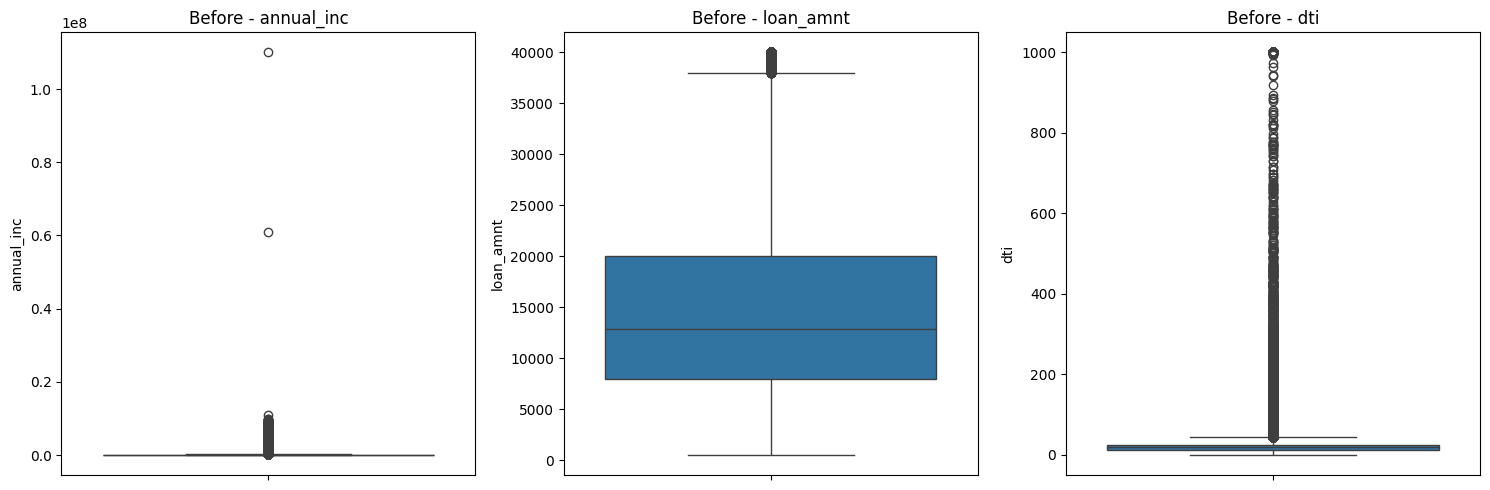

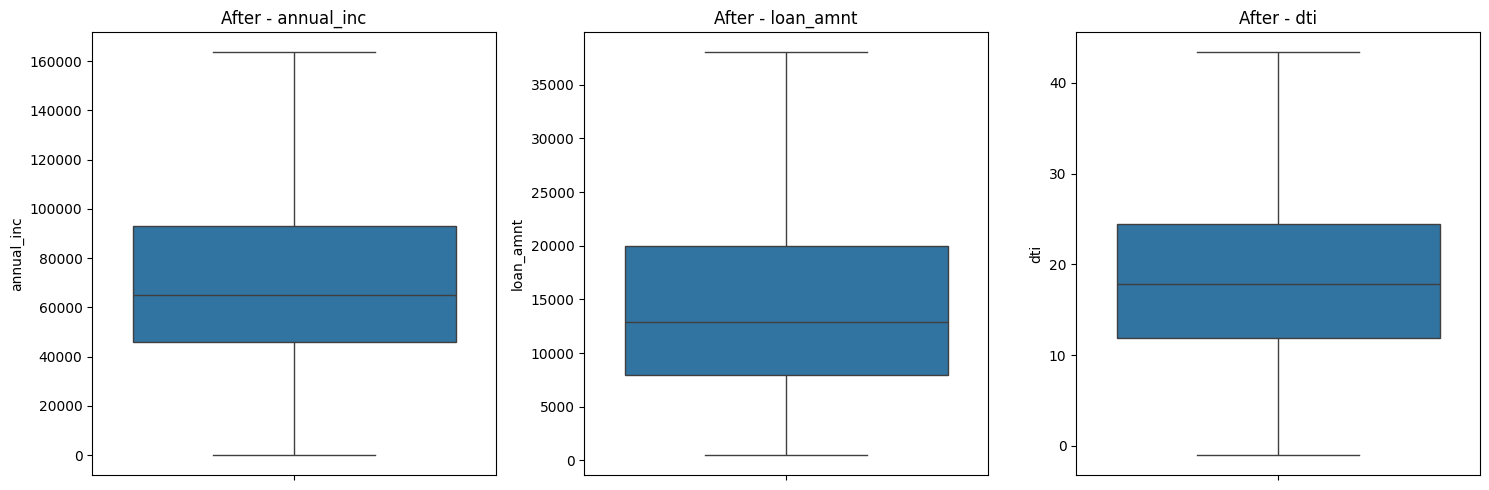

In [ ]:
# Các biến cần xử lý
cols = ['annual_inc', 'loan_amnt', 'dti']
#Before
df_before = df.copy()

plt.figure(figsize=(15,5))
for i, col in enumerate(cols, 1):
    plt.subplot(1,3,i)
    sns.boxplot(y=df_before[col])
    plt.title(f'Before - {col}')
plt.tight_layout()
plt.show()
# Clipping
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)
#After
plt.figure(figsize=(15,5))
for i, col in enumerate(cols, 1):
    plt.subplot(1,3,i)
    sns.boxplot(y=df[col])
    plt.title(f'After - {col}')
plt.tight_layout()
plt.show()

Trước khi xử lý, các biến annual_inc, loan_amnt và dti xuất hiện nhiều giá trị ngoại lai, thể hiện qua các điểm nằm ngoài phạm vi whisker của boxplot. Sau khi áp dụng phương pháp IQR với kỹ thuật clipping, các giá trị cực đoan đã được điều chỉnh về ngưỡng hợp lý thay vì bị loại bỏ. Điều này giúp giữ nguyên số lượng quan sát, đồng thời làm cho phân phối dữ liệu ổn định hơn, giảm ảnh hưởng tiêu cực đến mô hình hồi quy

### **1.2. Mã hóa biến định tính**

In [ ]:
# Bước 1: Xác định các biến định tính trong df
cat_cols = df.select_dtypes(include=['object']).columns

print("Các biến định tính:")
print(cat_cols)

Các biến định tính:
Index(['term', 'purpose', 'home_ownership', 'verification_status', 'grade'], dtype='object')


In [ ]:
# Bước 2: Kiểm tra số lượng giá trị & ví dụ
for col in cat_cols:
    print(f"\n - {col}")
    print("Số lượng giá trị khác nhau:", df[col].nunique())
    print("Ví dụ:", df[col].unique()[:5])


 - term
Số lượng giá trị khác nhau: 2
Ví dụ: [' 36 months' ' 60 months']

 - purpose
Số lượng giá trị khác nhau: 14
Ví dụ: ['debt_consolidation' 'small_business' 'home_improvement' 'major_purchase'
 'credit_card']

 - home_ownership
Số lượng giá trị khác nhau: 6
Ví dụ: ['MORTGAGE' 'RENT' 'OWN' 'ANY' 'NONE']

 - verification_status
Số lượng giá trị khác nhau: 3
Ví dụ: ['Not Verified' 'Source Verified' 'Verified']

 - grade
Số lượng giá trị khác nhau: 7
Ví dụ: ['C' 'B' 'F' 'A' 'E']


Kết quả cho thấy các biến định tính có số lượng giá trị khác nhau ở mức vừa phải, không có biến nào có cardinality quá cao nên đều có thể sử dụng cho mô hình.

- term (2 giá trị):
Chỉ gồm “36 months” và “60 months”, là biến có ít giá trị và có thể chuyển về dạng số (36, 60) hoặc mã hóa đơn giản.
- purpose (14 giá trị):
Biểu thị mục đích vay vốn, có số lượng giá trị trung bình → phù hợp với One-hot encoding để giữ thông tin chi tiết.
- home_ownership (6 giá trị):
Thể hiện tình trạng sở hữu nhà, số lượng giá trị ít → có thể dùng One-hot encoding.
- verification_status (3 giá trị):
Có số lượng giá trị rất nhỏ → dễ dàng mã hóa bằng One-hot encoding hoặc label encoding.
- grade (7 giá trị):
Là biến thể hiện mức độ rủi ro tín dụng, có thứ tự rõ ràng (A → G) → nên mã hóa bằng label encoding để giữ thông tin thứ bậc.

In [ ]:
#Bước 3: Mã hóa:
# 1. Xử lý biến có thể chuyển về số
# term: "36 months" → 36
if 'term' in df.columns:
    df['term'] = df['term'].astype(str).str.extract(r'(\d+)').astype(float)
# grade: A → 1, B → 2, ..., G → 7 (giữ thứ tự rủi ro)
if 'grade' in df.columns:
    grade_map = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7}
    df['grade'] = df['grade'].map(grade_map)
# 3. One-hot encoding cho các cột object còn lại
cat_cols = df.select_dtypes(include='object').columns.tolist()
# đảm bảo grade không bị encode lại
if 'grade' in cat_cols:
    cat_cols.remove('grade')

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# 3. Kiểm tra
print("Số cột object còn lại:", df.select_dtypes(include='object').shape[1])
print("Missing còn lại:", df.isnull().sum().sum())
print("Shape dữ liệu:", df.shape)

Số cột object còn lại: 0
Missing còn lại: 0
Shape dữ liệu: (2260701, 41)


Các biến định tính được mã hóa nhằm chuyển đổi dữ liệu về dạng số phù hợp với mô hình. Cụ thể, biến term được chuyển về dạng số để giữ ý nghĩa thứ tự của thời hạn vay, trong khi biến grade được mã hóa theo thứ bậc từ A đến G nhằm phản ánh mức độ rủi ro tín dụng. Các biến định tính còn lại được xử lý bằng phương pháp One-hot encoding để đảm bảo không làm mất thông tin. Sau khi mã hóa, dữ liệu không còn biến dạng chuỗi và sẵn sàng cho bước xây dựng mô hình.

## **2. Khám phá dữ liệu và trực quan hóa**

### **2.1 Khám phá dữ liệu**


 Histogram được sử dụng để quan sát phân phối của biến lãi suất (int_rate), từ đó xác định xu hướng và phát hiện sự lệch dữ liệu. Scatter plot giúp phân tích mối quan hệ giữa các biến số như điểm tín dụng (fico_range_high) và thu nhập (annual_inc) với lãi suất, nhằm đánh giá mức độ ảnh hưởng của từng yếu tố. Boxplot được sử dụng để so sánh sự khác biệt về lãi suất giữa các nhóm rủi ro (grade), từ đó làm rõ tác động của phân loại tín dụng.

Các biến được lựa chọn bao gồm int_rate, fico_range_high, annual_inc và grade vì đây là những yếu tố cốt lõi trong bài toán tín dụng. Lãi suất (int_rate) là biến mục tiêu cần phân tích, trong khi điểm tín dụng (fico_range_high) và phân loại rủi ro (grade) phản ánh mức độ uy tín tài chính của khách hàng. Thu nhập (annual_inc) đại diện cho khả năng trả nợ. Việc lựa chọn các biến này giúp tập trung vào những yếu tố có ý nghĩa nghiệp vụ cao và ảnh hưởng trực tiếp đến rủi ro tín dụng.


#### a. Phân phối biến mục tiêu

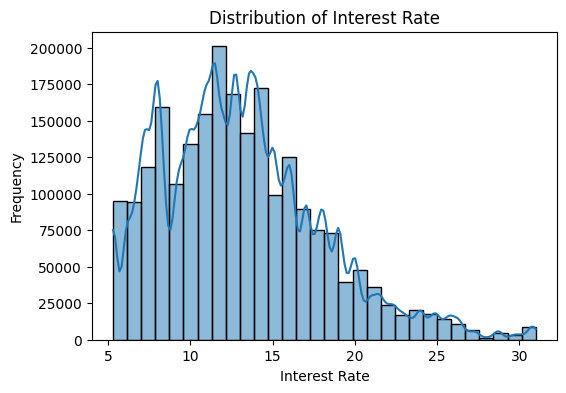

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df['int_rate'], bins=30, kde=True)

plt.title("Distribution of Interest Rate")
plt.xlabel("Interest Rate")
plt.ylabel("Frequency")

plt.show()

Biểu đồ cho thấy biến lãi suất (int_rate) có phân phối lệch phải (right-skewed), với phần lớn giá trị tập trung trong khoảng ~8% đến 15%, trong khi một số ít khoản vay có lãi suất rất cao (trên 20%–30%) tạo thành đuôi dài bên phải.

- Dữ liệu không phân phối chuẩn

→ Có thể ảnh hưởng đến mô hình hồi quy tuyến tính (vì Linear Regression giả định gần phân phối chuẩn).
- Có outlier (giá trị cao bất thường)

→ Có thể làm mô hình dự đoán sai lệch (bias về phía các giá trị lớn)

- Tập trung nhiều ở vùng trung bình

→ Mô hình sẽ học tốt hơn ở khoảng này, nhưng kém chính xác với lãi suất cao

#### b. SCATTER PLOT (Mối quan hệ) FICO Score vs Interest Rate

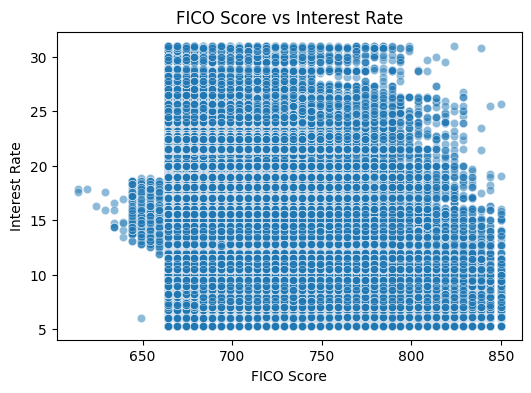

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='fico_range_high', y='int_rate', data=df, alpha=0.5)

plt.title("FICO Score vs Interest Rate")
plt.xlabel("FICO Score")
plt.ylabel("Interest Rate")

plt.show()


Biểu đồ scatter cho thấy mối quan hệ giữa fico_range_high (điểm tín dụng) và int_rate (lãi suất) có xu hướng nghịch (negative relationship). Khi điểm FICO tăng, lãi suất có xu hướng giảm.

Cụ thể, những khách hàng có điểm tín dụng thấp thường phải chịu mức lãi suất cao hơn, trong khi khách hàng có điểm tín dụng cao được hưởng lãi suất thấp hơn. Tuy nhiên, dữ liệu vẫn có sự phân tán, cho thấy lãi suất còn phụ thuộc vào nhiều yếu tố khác ngoài FICO score.

#### c. SCATTER PLOT (Mối quan hệ) Income vs Interest Rate

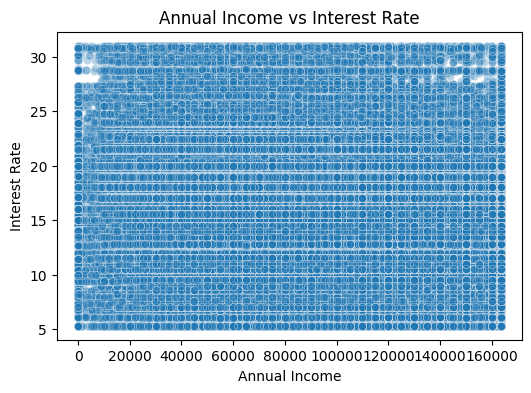

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='annual_inc',
    y='int_rate',
    data=df,
    alpha=0.3
)

plt.title("Annual Income vs Interest Rate")
plt.xlabel("Annual Income")
plt.ylabel("Interest Rate")

plt.show()

Biểu đồ scatter cho thấy mối quan hệ giữa thu nhập hàng năm (annual_inc) và lãi suất (int_rate) không rõ ràng. Các điểm dữ liệu phân bố dày và trải rộng trên toàn bộ không gian, không thể hiện xu hướng tuyến tính cụ thể.

Điều này cho thấy thu nhập không phải là yếu tố quyết định trực tiếp đến lãi suất. Mặc dù thu nhập phản ánh khả năng tài chính của khách hàng, nhưng trong thực tế, lãi suất phụ thuộc nhiều hơn vào các yếu tố đánh giá rủi ro như điểm tín dụng (FICO), lịch sử trả nợ và tình trạng tín dụng

#### d. Boxplot – so sánh lãi suất theo nhóm

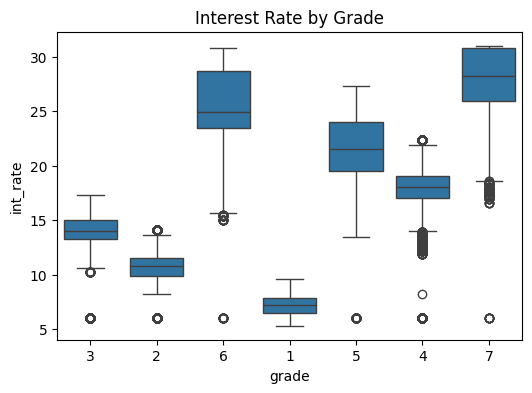

In [ ]:
# kiểm tra cột grade có tồn tại không
if 'grade' in df.columns and 'int_rate' in df.columns:

    # đảm bảo grade là dạng category (tốt cho boxplot)
    df['grade'] = df['grade'].astype(str)

    plt.figure(figsize=(6,4))
    sns.boxplot(x='grade', y='int_rate', data=df)

    plt.title("Interest Rate by Grade")
    plt.xticks(rotation=0)

    plt.show()

else:
    print("Không tìm thấy cột 'grade' hoặc 'int_rate' trong df")

Biểu đồ boxplot cho thấy lãi suất (int_rate) tăng dần theo từng nhóm grade từ A đến G. Các khoản vay thuộc nhóm A có lãi suất thấp nhất, trong khi nhóm G có lãi suất cao nhất.Đồng thời cũng xuất hiện một số giá trị ngoại lai (outliers) trong nhiều nhóm. Điều này cho thấy grade phản ánh trực tiếp mức độ rủi ro của khách hàng.


### **2.2. PCA (Giảm chiều dữ liệu)**

In [ ]:
#Bước 1: Tách X, y và chuẩn hóa
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['int_rate'])
y = df['int_rate']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
#Bước 2: Áp dụng PCA (2 thành phần):
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

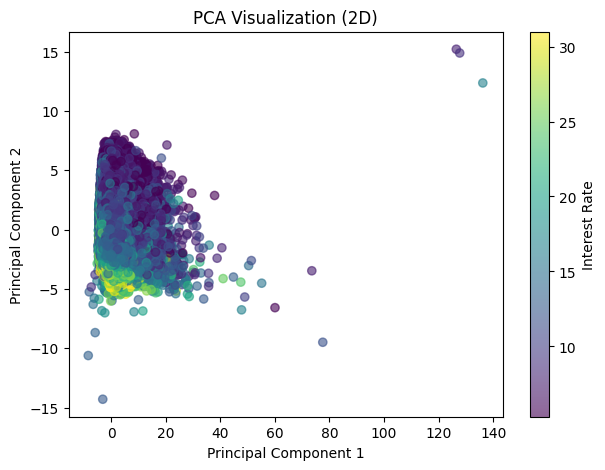

In [ ]:
#Bước 3: Trực quan PCA
plt.figure(figsize=(7,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Interest Rate')
plt.title("PCA Visualization (2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Sau khi giảm chiều dữ liệu bằng PCA, dữ liệu được chiếu về 2 thành phần chính (Principal Component 1 và 2), giúp đơn giản hóa không gian nhiều chiều ban đầu nhưng vẫn giữ được phần lớn thông tin quan trọng.

Ta thấy dữ liệu tập trung khá dày ở khu vực bên trái (PC1 nhỏ), cho thấy phần lớn mẫu có đặc trưng tương đối giống nhau. Tuy nhiên vẫn có một số điểm phân tán xa (outliers) ở phía bên phải và phía trên/dưới, chứng tỏ tồn tại những nhóm dữ liệu khác biệt hoặc giá trị bất thường.

Về màu sắc (Interest Rate), có thể thấy xu hướng không phân bố hoàn toàn ngẫu nhiên: một số vùng có màu cao (vàng/xanh sáng) tập trung khác với vùng màu thấp (tím), cho thấy Interest Rate có liên hệ nhất định với cấu trúc dữ liệu sau khi giảm chiều, dù không tách thành cụm rõ ràng.

##**3. Xây dựng mô hình hồi quy tuyến tính đa biến để dự đoán lãi suất**

In [ ]:
# Train-test split & CV
from sklearn.model_selection import train_test_split, cross_validate, KFold, RandomizedSearchCV
# Chuẩn hóa dữ liệu
from sklearn.preprocessing import StandardScaler, FunctionTransformer
# Mô hình hồi quy
from sklearn.linear_model import Ridge, Lasso
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.model_selection import GridSearchCV
from scipy.stats import shapiro
# Mô hình ML nâng cao
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
# Đánh giá mô hình
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# Pipeline (tránh data leakage)
from sklearn.pipeline import Pipeline
# Thống kê & kiểm định
import scipy.stats as stats
# Đại số tuyến tính (VIF, ma trận)
from scipy import linalg
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

###a. Xây dựng mô hình hồi quy đơn giản từ tất cả các biến đầu vào.

####Chia dữ liệu thành tập huấn luyện

In [ ]:
# Chia dữ liệu thành tập huấn luyện
X = df.drop(columns=['int_rate'])
y = df['int_rate']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


#### Chuẩn hóa dữ liệu, huấn luyện và đánh giá mô hình

In [ ]:
# Tạo pipeline (scale + model cùng lúc)
linear_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Huấn luyện
linear_pipeline.fit(X_train, y_train)

# Dự đoán
y_pred_linear = linear_pipeline.predict(X_test)

# Đánh giá mô hình
r2 = r2_score(y_test, y_pred_linear)
mae = mean_absolute_error(y_test, y_pred_linear)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))

print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2: 0.9173598546579074
MAE: 1.0743192978030496
RMSE: 1.3891205937836635


**Chia dữ liệu Train/Test**

Dữ liệu được tách thành biến đầu vào (X) và biến mục tiêu (y – lãi suất), sau đó chia thành tập huấn luyện và kiểm tra theo tỷ lệ 80/20.
Mục tiêu của bước này là đảm bảo mô hình được đánh giá trên dữ liệu chưa từng thấy, từ đó phản ánh đúng khả năng tổng quát hóa.

**Chuẩn hóa và huấn luyện mô hình**

Mô hình được xây dựng thông qua một pipeline kết hợp giữa chuẩn hóa dữ liệu và hồi quy tuyến tính.

StandardScaler giúp đưa các biến về cùng thang đo (mean = 0, std = 1), tránh tình trạng biến có giá trị lớn chi phối mô hình.
LinearRegression học mối quan hệ tuyến tính giữa các đặc trưng và lãi suất.

Việc dùng pipeline đảm bảo quá trình xử lý dữ liệu và huấn luyện diễn ra nhất quán, tránh rò rỉ dữ liệu giữa train và test.

**Đánh giá mô hình**

R²:
R² = 0.917 → mô hình giải thích được khoảng 91.7% sự biến thiên của lãi suất ⇒ mức độ phù hợp rất cao.

MAE:
MAE = 1.07 → sai số trung bình khoảng 1.07 ⇒ dự đoán khá sát với thực tế.

RMSE:
RMSE = 1.39 → sai số có xét đến các giá trị lệch lớn ⇒ vẫn tồn tại một số sai lệch nhưng không đáng kể.

**Nhận xét**

Kết quả cho thấy mô hình hồi quy tuyến tính hoạt động rất tốt trên dữ liệu. Sai số thấp và ổn định, đồng thời không có sự chênh lệch lớn giữa MAE và RMSE, cho thấy dữ liệu không bị ảnh hưởng mạnh bởi các ngoại lệ.

###b. Kiểm tra giả định mô hình.

####Phân phối chuẩn của phần dư

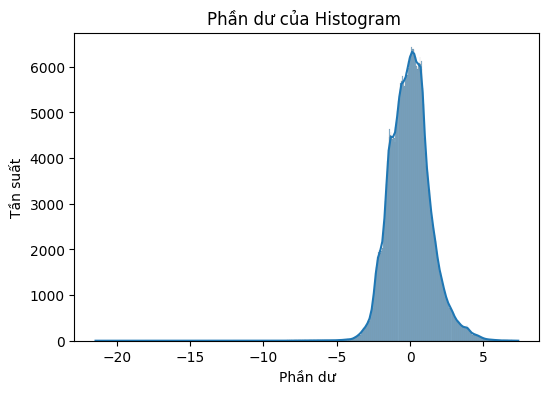

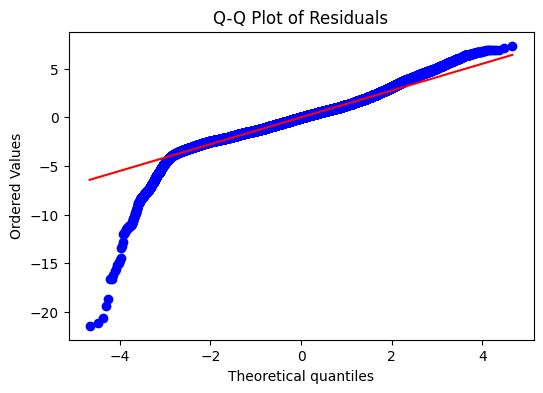

Shapiro-Wilk p-value: 1.0839347181626432e-24


In [ ]:
# Phần dư
y_pred_linear = linear_pipeline.predict(X_test)
residuals = y_test - y_pred_linear

# Histogram
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Phần dư của Histogram ")
plt.xlabel("Phần dư")
plt.ylabel("Tần suất")
plt.show()

# Q-Q plot
plt.figure(figsize=(6,4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Kiểm định Shapiro-Wilk
sample_residuals = residuals.sample(
    n=min(5000, len(residuals)),
    random_state=42
)

stat, p_value = shapiro(sample_residuals)

print("Shapiro-Wilk p-value:", p_value)

**Tính phần dư**

Phần dư được xác định bằng chênh lệch giữa giá trị thực tế và giá trị dự đoán:

residuals = y_test - y_pred_linear

Bước này giúp đánh giá mô hình đang sai ở đâu và sai như thế nào.

**Phân phối phần dư (Histogram)**

Biểu đồ Histogram cho thấy phần dư tập trung quanh 0, chứng tỏ phần lớn dự đoán khá chính xác. Tuy nhiên, phân phối có xu hướng lệch trái (đuôi âm dài), nghĩa là tồn tại một số trường hợp mô hình dự đoán cao hơn thực tế khá nhiều.

→ Điều này cho thấy mô hình vẫn bị ảnh hưởng bởi outliers hoặc các quan hệ phi tuyến chưa được học hết.

**Q-Q Plot**

Q-Q plot so sánh phân phối phần dư với phân phối chuẩn. Các điểm nằm sát đường thẳng ở vùng trung tâm → phù hợp khá tốt. Lệch mạnh ở hai đầu → đặc biệt phía âm.

Phần dư không hoàn toàn tuân theo phân phối chuẩn, có hiện tượng sai số lớn ở các cực trị.

**Kiểm định Shapiro-Wilk**

p-value ≈ 1.08e-24, p-value rất nhỏ (< 0.05) → Bác bỏ giả thuyết phần dư phân phối chuẩn.

Tuy nhiên, với kích thước mẫu lớn, Shapiro-Wilk rất nhạy và dễ bác bỏ giả thuyết chuẩn hóa ngay cả khi sai lệch nhỏ. Vì vậy, cần kết hợp với histogram và Q-Q plot để đánh giá thực tế.

**Nhận xét**

Mặc dù mô hình hồi quy tuyến tính đạt hiệu suất cao, nhưng phân tích phần dư cho thấy:

Phần dư không phân phối chuẩn. Xuất hiện các sai số lớn (đuôi dài). Có dấu hiệu mô hình chưa bắt được hết tính phi tuyến của dữ liệu. Điều này giải thích vì sao vẫn tồn tại một số dự đoán lệch đáng kể.

####Hiện tượng đa cộng tuyến

In [ ]:
# Chỉ lấy biến số
X_vif = X_train.select_dtypes(include=[np.number]).copy()

# Loại bỏ cột có variance = 0
X_vif = X_vif.loc[:, X_vif.var() > 0]

# Xử lý NaN / inf
X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna()

# Giảm tương quan cao
corr_matrix = X_vif.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Loại bỏ biến có tương quan > 0.95
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.95)]

X_vif = X_vif.drop(columns=to_drop_corr)

print("Số biến sau khi giảm tương quan:", X_vif.shape[1])

# Lấy sample
sample_size = min(5000, len(X_vif))
X_sample = X_vif.sample(n=sample_size, random_state=42)

# Tính VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X_sample.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_sample.values, i)
    for i in range(X_sample.shape[1])
]

vif_data = vif_data.sort_values(by="VIF", ascending=False)

print("\nTop 15 VIF:")
print(vif_data.head(15))

# Loại bỏ biến có VIF cao
high_vif_features = vif_data[vif_data["VIF"] > 10]["feature"]

print("\nBiến bị loại do VIF cao:", list(high_vif_features))

# Loại bỏ khỏi train & test
X_train_final = X_train.drop(columns=high_vif_features, errors='ignore')
X_test_final = X_test.drop(columns=high_vif_features, errors='ignore')

Số biến sau khi giảm tương quan: 18

Top 15 VIF:
             feature         VIF
0          loan_amnt  116.515162
2        installment   97.392649
1               term   53.025737
5    fico_range_high   51.558450
11        revol_util   21.216744
16           bc_util   19.564970
8           open_acc   15.752285
12         total_acc   13.111765
14  total_rev_hi_lim   12.554675
13       tot_cur_bal   11.176466
3         annual_inc   10.029308
10         revol_bal    8.449021
15       avg_cur_bal    7.867252
4                dti    7.660959
17          mort_acc    2.667195

Biến bị loại do VIF cao: ['loan_amnt', 'installment', 'term', 'fico_range_high', 'revol_util', 'bc_util', 'open_acc', 'total_acc', 'total_rev_hi_lim', 'tot_cur_bal', 'annual_inc']


**Xử lý dữ liệu ban đầu**

Dữ liệu được lọc chỉ giữ các biến số, đồng thời loại bỏ các biến có variance = 0 vì những biến này không mang thông tin cho mô hình.
Ngoài ra, các giá trị bất thường như NaN hoặc vô cực (inf) cũng được xử lý để tránh làm sai lệch kết quả khi tính toán.

**Giảm tương quan cao**

Ma trận tương quan được sử dụng để loại bỏ các biến có mức tương quan lớn hơn **0.95**.
Đây là ngưỡng rất cao, chỉ loại những biến gần như trùng lặp thông tin.

Sau bước này, số biến giảm còn **18 biến** → giúp giảm đáng kể hiện tượng đa cộng tuyến ngay từ đầu.

**Tính VIF**

VIF được tính trên mẫu tối đa **5000 dòng** (`min(5000, len(X))`) nhằm giảm thời gian tính toán nhưng vẫn giữ được tính đại diện.

Kết quả cho thấy nhiều biến có VIF rất lớn:

* loan_amnt ≈ 116
* installment ≈ 97
* term ≈ 53
* fico_range_high ≈ 51

Các giá trị này đều lớn hơn rất nhiều so với ngưỡng 10 → cho thấy **đa cộng tuyến nghiêm trọng**, tức là các biến này đang chứa thông tin chồng chéo lẫn nhau.


**Loại biến theo VIF**

Sử dụng ngưỡng **VIF > 10**, mô hình loại bỏ tổng cộng **11 biến**.
Phần lớn các biến bị loại thuộc nhóm tài chính (khoản vay, dư nợ, tài sản…), vốn có xu hướng liên hệ chặt chẽ với nhau trong thực tế.

Việc loại các biến này giúp:

* Tránh hệ số hồi quy bị phóng đại
* Giảm nhiễu trong mô hình
* Tăng khả năng giải thích


**Kết luận**

Quy trình gồm hai bước: loại tương quan cao (>0.95) và loại VIF cao (>10) đã xử lý hiệu quả đa cộng tuyến.
Sau khi lọc, bộ dữ liệu trở nên gọn hơn và các biến còn lại mang thông tin độc lập hơn, giúp mô hình hồi quy tuyến tính ổn định và đáng tin cậy hơn khi dự đoán.



###c. Tạo biến mới

In [ ]:
def feature_engineering(X):
    X = X.copy()

    # Biến đổi log
    for col in ['annual_inc', 'loan_amnt']:
        if col in X.columns:
            X[f'log_{col}'] = np.log1p(X[col])

    # Biến tương tác
    if 'dti' in X.columns and 'annual_inc' in X.columns:
        X['dti_income'] = X['dti'] * X['annual_inc']

    # Biến tỷ lệ
    if 'loan_amnt' in X.columns and 'annual_inc' in X.columns:
        X['loan_income_ratio'] = X['loan_amnt'] / (X['annual_inc'] + 1)

    return X


###d. Chỉnh hóa mô hình.

####Dùng lại feature sau khi xử lý tương quan

In [ ]:
# Tạo feature mới cho train/test
X_train_fe = feature_engineering(X_train_final)
X_test_fe  = feature_engineering(X_test_final)

# Đồng bộ cột giữa train và test
common_cols = X_train_fe.columns.intersection(X_test_fe.columns)

X_train_clean = X_train_fe[common_cols].copy()
X_test_clean  = X_test_fe[common_cols].copy()

In [ ]:
# XỬ LÝ KIỂU DỮ LIỆU + GIÁ TRỊ THIẾU
# ép toàn bộ object → numeric nếu có thể
for col in X_train_clean.columns:
    if X_train_clean[col].dtype == 'object':
        X_train_clean[col] = pd.to_numeric(X_train_clean[col], errors='coerce')
        X_test_clean[col] = pd.to_numeric(X_test_clean[col], errors='coerce')

# Lấy các cột dạng số
num_cols = X_train_clean.select_dtypes(include=[np.number]).columns

# Điền median cho các cột số
X_train_clean[num_cols] = X_train_clean[num_cols].fillna(X_train_clean[num_cols].median())
X_test_clean[num_cols] = X_test_clean[num_cols].fillna(X_test_clean[num_cols].median())

# Đảm bảo không còn giá trị thiếu
X_train_clean = X_train_clean.fillna(0)
X_test_clean = X_test_clean.fillna(0)

####Pipeline Ridge và Pipeline Lasso

In [ ]:
# Pipeline Ridge
ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', RidgeCV(alphas=[0.1, 1, 10, 50, 100], cv=3))
])

ridge_model.fit(X_train_clean, y_train)
y_pred_ridge = ridge_model.predict(X_test_clean)

# Pipeline Lasso
lasso_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(alphas=[0.001, 0.01, 0.1, 1, 10], cv=3, max_iter=5000))
])

lasso_model.fit(X_train_clean, y_train)
y_pred_lasso = lasso_model.predict(X_test_clean)

####So sánh đầy đủ với Linear

In [ ]:
def evaluate(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

# Linear (train lại cho đúng feature)
linear_model = Pipeline([
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

linear_model.fit(X_train_clean, y_train)
y_pred_linear = linear_model.predict(X_test_clean)

# So sánh
results = {
    "Linear": evaluate(y_test, y_pred_linear),
    "Ridge": evaluate(y_test, y_pred_ridge),
    "Lasso": evaluate(y_test, y_pred_lasso)
}

print(pd.DataFrame(results).T.round(4))

            R2     MAE    RMSE
Linear  0.9092  1.1246  1.4561
Ridge   0.9092  1.1246  1.4561
Lasso   0.9092  1.1246  1.4562


**Xây dựng và huấn luyện mô hình**

Mô hình Linear được huấn luyện lại trên tập dữ liệu đã xử lý (`X_train_clean`) nhằm đảm bảo sử dụng đúng các đặc trưng sau khi loại đa cộng tuyến.

Pipeline được sử dụng để kết hợp chuẩn hóa (`StandardScaler`) và hồi quy tuyến tính (`LinearRegression`), giúp đảm bảo dữ liệu được xử lý nhất quán và tránh rò rỉ dữ liệu giữa train và test.

Hai mô hình Ridge và Lasso cũng được sử dụng để so sánh, trong đó có áp dụng regularization nhằm kiểm soát độ phức tạp của mô hình.

**Đánh giá mô hình**

Ba chỉ số được sử dụng gồm R², MAE và RMSE để đánh giá hiệu quả dự đoán.

- **R²** ≈ 0.909 → mô hình giải thích được khoảng 90.9% sự biến thiên của lãi suất, cho thấy mức độ phù hợp rất cao.

- **MAE** ≈ 1.1246 → sai số trung bình thấp và gần như không khác biệt giữa các mô hình, chứng tỏ dự đoán ổn định.

- **RMSE** ≈ 1.456 → có xét đến sai số lớn, tuy nhiên không chênh lệch nhiều so với MAE, cho thấy không có nhiều ngoại lệ ảnh hưởng mạnh.

**So sánh mô hình**

Kết quả cho thấy Linear, Ridge và Lasso cho hiệu năng gần như giống nhau.

Nguyên nhân là do dữ liệu đã được xử lý tốt từ trước:
- Đã loại đa cộng tuyến bằng VIF  
- Số lượng biến không quá lớn  
- Quan hệ giữa biến đầu vào và đầu ra mang tính tuyến tính rõ ràng  

Vì vậy, regularization trong Ridge và Lasso không mang lại cải thiện đáng kể.

- **Kết luận**

Ba mô hình đều cho kết quả tốt và ổn định, tuy nhiên không có sự khác biệt rõ rệt giữa chúng. Trong trường hợp này, mô hình Linear là lựa chọn phù hợp nhất vì đơn giản, dễ giải thích và vẫn đảm bảo độ chính xác cao.


###e. Đánh giá mô hình bằng K-Fold Cross Validation

In [ ]:
# KFold và scoring
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error'
}

# Định nghĩa mô hình
models = {
    "Linear": Pipeline([
        ("fe", FunctionTransformer(feature_engineering)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("fe", FunctionTransformer(feature_engineering)),
        ("scaler", StandardScaler()),
        ("model", RidgeCV(alphas=[0.1, 1, 10, 50, 100], cv=3))
    ]),
    "Lasso": Pipeline([
        ("fe", FunctionTransformer(feature_engineering)),
        ("scaler", StandardScaler()),
        ("model", LassoCV(alphas=[0.001, 0.01, 0.1, 1, 10], max_iter=5000))
    ])
}

# Cross-validation
results = []

for name, mdl in models.items():
    cv_result = cross_validate(
        mdl,
        X_train_final,
        y_train,
        cv=kf,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "R2": cv_result['test_r2'].mean(),
        "MAE": -cv_result['test_mae'].mean(),
        "RMSE": np.sqrt(-cv_result['test_mse'].mean())
    })

results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)

print(results_df.round(4))

    Model      R2     MAE    RMSE
0  Linear  0.9091  1.1257  1.4572
1   Ridge  0.9091  1.1257  1.4572
2   Lasso  0.9091  1.1257  1.4572


**Thiết lập K-Fold Cross Validation**

Dữ liệu được đánh giá bằng phương pháp K-Fold với **n_splits = 5**, kết hợp `shuffle=True` và `random_state=42` để đảm bảo tính ngẫu nhiên nhưng vẫn có thể tái lập kết quả.

Ba chỉ số được sử dụng gồm:
- R² (đánh giá mức độ giải thích)
- MAE (sai số trung bình tuyệt đối)
- MSE → dùng để tính RMSE

**Xây dựng mô hình**

Ba mô hình được đưa vào so sánh gồm Linear, Ridge và Lasso.

Tất cả đều sử dụng pipeline chung:
- Feature Engineering (`FunctionTransformer`)
- Chuẩn hóa (`StandardScaler`)
- Mô hình hồi quy

Ridge sử dụng `RidgeCV` với các giá trị alpha [0.1, 1, 10, 50, 100] và cv=3 để tự chọn tham số tốt nhất.  
Lasso sử dụng `LassoCV` với nhiều mức alpha và `max_iter=5000` để đảm bảo hội tụ.

**Đánh giá kết quả**

- **R²** ≈ 0.9091 → mô hình giải thích được khoảng 90.9% sự biến thiên của lãi suất và duy trì ổn định qua các fold.

- **MAE** ≈ 1.1257 → sai số trung bình thấp và gần như không thay đổi giữa các lần chia dữ liệu.

- **RMSE** ≈ 1.4572 → sai số tổng thể ổn định, không xuất hiện biến động lớn giữa các fold.

**So sánh mô hình**

Kết quả cho thấy cả ba mô hình Linear, Ridge và Lasso đều cho hiệu năng gần như giống nhau trên tất cả các chỉ số.

Điều này cho thấy:
- Dữ liệu đã được xử lý tốt (loại đa cộng tuyến + feature engineering)  
- Mô hình không có dấu hiệu overfitting rõ rệt
- Quan hệ giữa biến đầu vào và đầu ra mang tính tuyến tính rõ ràng  

Do đó, regularization trong Ridge và Lasso không mang lại cải thiện đáng kể.

**Kết luận**

K-Fold Cross Validation cho thấy mô hình có độ ổn định cao và khả năng tổng quát hóa tốt trên nhiều tập dữ liệu khác nhau. Trong trường hợp này, mô hình Linear là lựa chọn hợp lý vì đơn giản, dễ giải thích và vẫn đảm bảo hiệu quả dự đoán tương đương các mô hình phức tạp hơn.



##**4. So sánh với mô hình học máy phi tuyến**

###Chuẩn bị dữ liệu cho mô hình

In [ ]:
# 1. Feature engineering trước
X_train_fe = feature_engineering(X_train_final)
X_test_fe  = feature_engineering(X_test_final)

# 2. Đảm bảo tồn tại cột grade
if 'grade' not in X_train_fe.columns:
    X_train_fe['grade'] = 0
if 'grade' not in X_test_fe.columns:
    X_test_fe['grade'] = 0

# 3. Đồng bộ toàn bộ cột
all_cols = X_train_fe.columns.union(X_test_fe.columns)

X_train_fe = X_train_fe.reindex(columns=all_cols, fill_value=0)
X_test_fe  = X_test_fe.reindex(columns=all_cols, fill_value=0)

# 4. Chuyển toàn bộ sang dạng số
for col in X_train_fe.columns:
    X_train_fe[col] = pd.to_numeric(X_train_fe[col], errors='coerce')
    X_test_fe[col]  = pd.to_numeric(X_test_fe[col], errors='coerce')

# 5. Xử lý NaN
X_train_fe = X_train_fe.fillna(0)
X_test_fe  = X_test_fe.fillna(0)

# 6. Lưu lại dùng cho huấn luyện mô hình
X_train_force = X_train_fe.copy()
X_test_force  = X_test_fe.copy()

###Tối ưu hóa siêu tham số cho random forest và xgboost

In [ ]:
# lấy mẫu dữ liệu
n_sample = min(10000, len(X_train_final))   # giảm cho nhẹ
X_sample = X_train_final.sample(n=n_sample, random_state=42)
y_sample = y_train.loc[X_sample.index]


# xử lý kiểu dữ liệu + giá trị thiếu
# object → numeric
for col in X_sample.columns:
    if X_sample[col].dtype == 'object':
        X_sample[col] = pd.to_numeric(X_sample[col], errors='coerce')

# điền giá trị thiếu
X_sample = X_sample.fillna(0)


# RANDOM FOREST
rf_pipeline = Pipeline([
    ("fe", FunctionTransformer(feature_engineering, validate=False)),
    ("rf", RandomForestRegressor(random_state=42, n_jobs=1))
])

rf_param_grid = {
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [8, 12],
    'rf__max_features': ['sqrt'],
    'rf__min_samples_split': [5],
    'rf__min_samples_leaf': [1]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_param_grid,
    n_iter=3,
    cv=2,
    scoring='r2',
    random_state=42,
    n_jobs=1
)

rf_search.fit(X_sample, y_sample)

# XGBOOST
xgb_pipeline = Pipeline([
    ("fe", FunctionTransformer(feature_engineering, validate=False)),
    ("xgb", xgb.XGBRegressor(
        tree_method='hist',
        eval_metric='rmse',
        random_state=42,
        n_jobs=1,
        enable_categorical=False
    ))
])

xgb_param_grid = {
    'xgb__n_estimators': [50, 100],
    'xgb__learning_rate': [0.1],
    'xgb__max_depth': [3],
    'xgb__subsample': [0.8],
    'xgb__colsample_bytree': [0.8]
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    n_iter=3,
    cv=2,
    scoring='r2',
    random_state=42,
    n_jobs=1
)

xgb_search.fit(X_sample, y_sample)

# Mô hình tốt nhất
rf_best = rf_search.best_estimator_
xgb_best = xgb_search.best_estimator_

print("Tham số RF tốt nhất :", rf_search.best_params_)
print("Tham số XGB tốt nhất:", xgb_search.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=3. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Tham số RF tốt nhất : {'rf__n_estimators': 100, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 1, 'rf__max_features': 'sqrt', 'rf__max_depth': 12}
Tham số XGB tốt nhất: {'xgb__subsample': 0.8, 'xgb__n_estimators': 100, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.1, 'xgb__colsample_bytree': 0.8}


**Chuẩn bị dữ liệu và tối ưu tính toán**

Dữ liệu huấn luyện không được sử dụng toàn bộ mà lấy mẫu tối đa **10,000 dòng** (`min(10000, len(X_train_final))`).
Việc sampling này giúp giảm đáng kể thời gian chạy khi tuning, đặc biệt với các mô hình như Random Forest và XGBoost vốn khá nặng. Tuy nhiên, do chọn ngẫu nhiên với `random_state=42`, mẫu vẫn đảm bảo tính đại diện và không làm lệch phân phối dữ liệu.

Ngoài ra, dữ liệu được ép về dạng số (`to_numeric`) và xử lý giá trị thiếu bằng cách thay bằng **0**. Điều này đảm bảo mô hình không bị lỗi khi huấn luyện, nhưng cũng có thể làm mất một phần thông tin nếu NaN mang ý nghĩa đặc biệt.

**Random Forest**

Kết quả tuning cho thấy mô hình tốt nhất với:

* `n_estimators = 100`: số lượng cây đủ lớn để mô hình học được nhiều pattern, nhưng chưa quá lớn để gây chậm.
* `max_depth = 12`: giới hạn độ sâu giúp tránh việc cây học quá chi tiết → giảm overfitting.
* `min_samples_split = 5`: yêu cầu tối thiểu 5 mẫu để tách nhánh → làm mô hình “thận trọng” hơn khi chia cây.

Cách chọn tham số này cho thấy mô hình đang được kiểm soát theo hướng **giảm độ phức tạp**, tránh học nhiễu từ dữ liệu.

**XGBoost**

Mô hình XGBoost có cấu hình:

* `max_depth = 3`: cây rất nông → giảm mạnh nguy cơ overfitting.
* `learning_rate = 0.1`: tốc độ học vừa phải, không quá nhanh để tránh bỏ sót pattern.
* `subsample = 0.8`, `colsample_bytree = 0.8`: mỗi cây chỉ học trên một phần dữ liệu → tăng tính ngẫu nhiên và khả năng tổng quát hóa.

Đây là cấu hình điển hình của XGBoost khi ưu tiên **tính ổn định và generalization** hơn là fit cực sát dữ liệu train.

**Nhận xét**

Cả hai mô hình đều được tuning với số vòng tìm kiếm khá nhỏ (`n_iter = 3`, `cv = 2`) → thời gian chạy nhanh nhưng không đảm bảo tìm được tham số tốt nhất trong phạm vi tìm kiếm.
Tuy nhiên, các tham số tìm được đều hợp lý và cho thấy xu hướng chung: **giảm độ phức tạp mô hình để tránh overfitting**.

Random Forest tận dụng nhiều cây với độ sâu vừa phải để học dữ liệu, trong khi XGBoost kiểm soát chặt hơn bằng cây nông và cơ chế học tuần tự.
Nhìn chung, cả hai mô hình đều phù hợp với bài toán và có khả năng dự đoán tốt trên dữ liệu mới.




###Huấn luyện mô hình tối ưu

In [ ]:
# Xử lý lại kiểu dữ liệu trước khi train
def fix_dtype(df):
    df = df.copy()
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df.fillna(0)

X_train_fix = fix_dtype(X_train_final)
X_test_fix = fix_dtype(X_test_final)

# huấn luyện và dự đoán với random forest
rf_best.fit(X_train_fix, y_train)
y_pred_rf = rf_best.predict(X_test_fix)

# huấn luyện và dự đoán với xgboost
xgb_best.fit(X_train_fix, y_train)
y_pred_xgb = xgb_best.predict(X_test_fix)

###Đánh giá mô hình

In [ ]:
def evaluate(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

rf_result = evaluate(y_test, y_pred_rf)
xgb_result = evaluate(y_test, y_pred_xgb)

results = pd.DataFrame({
    "Random Forest": rf_result,
    "XGBoost": xgb_result
}).T

print(results.round(4))

                   R2     MAE    RMSE
Random Forest  0.8743  1.2575  1.7132
XGBoost        0.9128  1.1019  1.4268


**Đánh giá mô hình**

Kết quả cho thấy XGBoost đạt **R² = 0.9128**, cao hơn so với Random Forest (**0.8743**).
Điều này nghĩa là XGBoost giải thích được khoảng **91.28%** biến thiên của lãi suất, trong khi Random Forest chỉ khoảng **87.43%**. Sự chênh lệch này khá rõ, cho thấy XGBoost nắm bắt cấu trúc dữ liệu tốt hơn.

Về sai số tuyệt đối trung bình, **MAE của XGBoost = 1.1019** thấp hơn Random Forest (**1.2575**).
Điều này cho thấy trung bình mỗi dự đoán của XGBoost gần với giá trị thực hơn, tức là mô hình này chính xác hơn trong hầu hết các trường hợp.

Xét đến RMSE, **XGBoost = 1.4268** cũng thấp hơn so với Random Forest (**1.7132**).
Do RMSE phạt mạnh các sai số lớn, kết quả này cho thấy XGBoost không chỉ chính xác trung bình mà còn **ít mắc lỗi lớn hơn**, tức là dự đoán ổn định hơn.

**Nhận xét**

Sự vượt trội của XGBoost đến từ cơ chế học tuần tự (boosting), trong đó mỗi cây mới sẽ tập trung sửa lỗi của cây trước đó. Điều này giúp mô hình học được các mối quan hệ phức tạp và phi tuyến tốt hơn so với Random Forest (vốn học độc lập giữa các cây).

Trong khi đó, Random Forest dù giúp giảm overfitting tốt nhờ tính ngẫu nhiên, nhưng đôi khi không bắt được các pattern tinh vi trong dữ liệu, dẫn đến độ chính xác thấp hơn.

**Kết luận**

XGBoost là mô hình phù hợp hơn cho bài toán này vì đạt kết quả tốt hơn trên cả 3 chỉ số (R² cao hơn, MAE và RMSE thấp hơn).
Random Forest vẫn hoạt động ổn định, nhưng không đạt được mức hiệu quả như XGBoost trong việc dự đoán lãi suất.



###Đánh giá và so sánh hiệu suất các mô hình hồi quy dựa trên các chỉ số đo lường

In [ ]:
# Cross validation
# Sửa kiểu dữ liệu
X_train_fix = X_train_final.apply(pd.to_numeric, errors='coerce').fillna(0)

kf = KFold(n_splits=3, shuffle=True, random_state=42)

models = {
    "Linear": Pipeline([
        ("fe", FunctionTransformer(feature_engineering, validate=False)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Random Forest": rf_best,
    "XGBoost": xgb_best
}

results = []

for name, model in models.items():
    cv = cross_validate(
        model,
        X_train_fix,   # dùng dữ liệu đã sửa
        y_train,
        cv=kf,
        scoring={
            'r2': 'r2',
            'mae': 'neg_mean_absolute_error',
            'mse': 'neg_mean_squared_error'
        },
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "R2": cv['test_r2'].mean(),
        "MAE": -cv['test_mae'].mean(),
        "RMSE": np.sqrt(-cv['test_mse'].mean())
    })

results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)

print(results_df.round(4))

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


           Model      R2     MAE    RMSE
2        XGBoost  0.9125  1.1030  1.4294
0         Linear  0.9091  1.1257  1.4572
1  Random Forest  0.8743  1.2558  1.7132


**Chuẩn bị dữ liệu trước Cross Validation**

Trước khi thực hiện K-Fold, dữ liệu được ép toàn bộ về dạng số (`to_numeric`) và thay giá trị thiếu bằng **0**.
Bước này đảm bảo các mô hình (đặc biệt là Linear và XGBoost) không bị lỗi khi huấn luyện, tuy nhiên việc thay NaN bằng 0 có thể làm giảm độ chính xác nếu giá trị thiếu mang ý nghĩa riêng.

Sử dụng **KFold với n_splits = 3** giúp đánh giá mô hình trên nhiều cách chia dữ liệu khác nhau, từ đó phản ánh tốt hơn khả năng tổng quát hóa. Việc `shuffle=True` và `random_state=42` đảm bảo kết quả ổn định và không bị phụ thuộc vào thứ tự dữ liệu.

**Kết quả đánh giá**

XGBoost đạt **R² = 0.9125**, cao nhất trong ba mô hình, cho thấy khả năng giải thích dữ liệu tốt nhất.
Linear đạt **0.9091**, gần như tương đương, chứng tỏ mối quan hệ trong dữ liệu phần lớn vẫn mang tính tuyến tính.
Random Forest thấp hơn (**0.8743**), cho thấy chưa tận dụng tốt cấu trúc dữ liệu.

Về sai số, **MAE của XGBoost = 1.1030** là thấp nhất, tiếp theo là Linear (**1.1257**).
Sự chênh lệch giữa hai mô hình này rất nhỏ (~0.02), nghĩa là hiệu suất thực tế gần như tương đương.
Random Forest có MAE cao hơn (**1.2558**), tức là dự đoán kém chính xác hơn.

Xét RMSE, **XGBoost = 1.4294** tiếp tục tốt nhất, Linear (**1.4572**) bám sát phía sau.
Random Forest (**1.7132**) cao hơn đáng kể, cho thấy mô hình này mắc nhiều sai số lớn hơn.

**Nhận xét**

Kết quả Cross Validation cho thấy thứ hạng mô hình rất ổn định: **XGBoost > Linear > Random Forest**, và điều này nhất quán với kết quả test trước đó.

Điểm đáng chú ý là Linear gần như không thua kém XGBoost, dù là mô hình đơn giản hơn rất nhiều. Điều này cho thấy sau khi xử lý dữ liệu (feature engineering + loại đa cộng tuyến), dữ liệu đã trở nên “dễ học” hơn và không còn quá phi tuyến.

**Kết luận**

XGBoost là mô hình tốt nhất về mặt hiệu suất và độ ổn định. Tuy nhiên, Linear Regression cũng là một lựa chọn rất mạnh vì kết quả gần tương đương nhưng dễ giải thích hơn. Random Forest cho kết quả thấp hơn rõ rệt, nên không phải lựa chọn tối ưu trong bài toán này.



###Trực quan hóa các đặc trưng quan trọng nhất của mô hình Random Forest và XGBoost

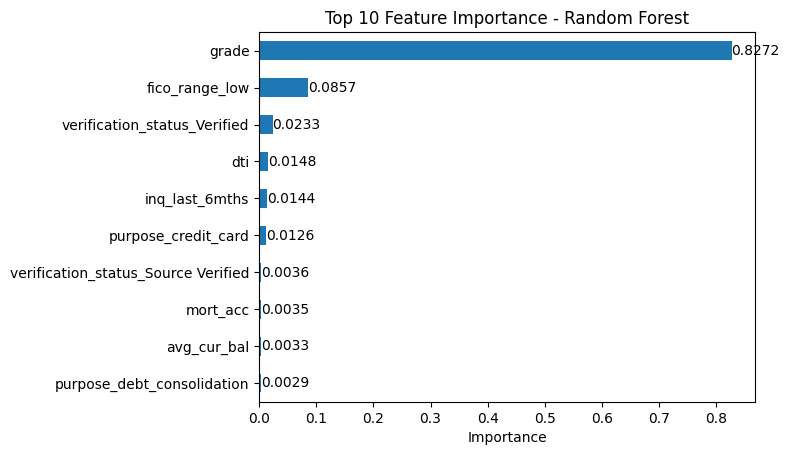

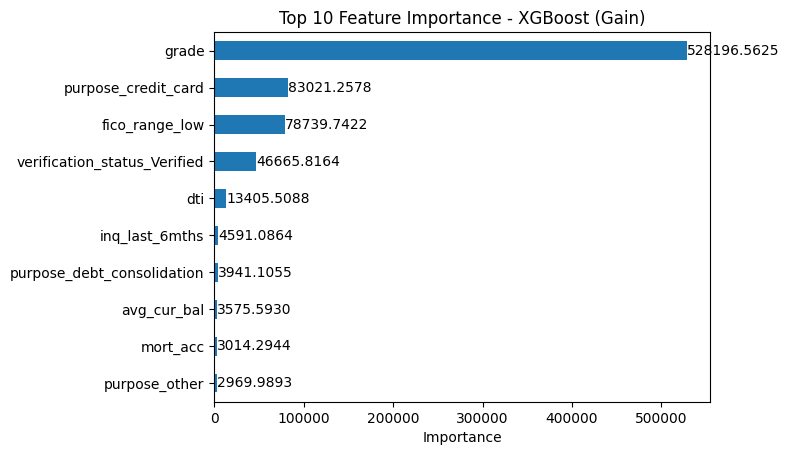

In [ ]:
# lấy đặc trưng từ pipeline

X_fe = feature_engineering(X_train_final)
feature_names = X_fe.columns

# random forest
rf_model = rf_best.named_steps['rf']

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

rf_top = rf_importance.head(10).sort_values()

plt.figure()
ax = rf_top.plot(kind='barh')

for i, v in enumerate(rf_top):
    ax.text(v, i, f"{v:.4f}", va='center')

plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()


# xgboost
xgb_model = xgb_best.named_steps['xgb']

raw_importance = xgb_model.get_booster().get_score(importance_type='gain')

xgb_importance = pd.Series(raw_importance).sort_values(ascending=False)

xgb_top = xgb_importance.head(10).sort_values()

plt.figure()
ax = xgb_top.plot(kind='barh')

for i, v in enumerate(xgb_top):
    ax.text(v, i, f"{v:.4f}", va='center')

plt.title("Top 10 Feature Importance - XGBoost (Gain)")
plt.xlabel("Importance")
plt.show()

**Phân tích mức độ quan trọng của biến (Feature Importance)**

Kết quả từ cả hai mô hình đều cho thấy biến **`grade`** có mức độ quan trọng vượt trội so với tất cả các biến còn lại.

Ở Random Forest, `grade` chiếm khoảng **0.8272** gần như toàn bộ khả năng dự đoán của mô hình tập trung vào biến này.
Điều này cho thấy chỉ riêng thông tin về phân loại tín dụng (grade) đã giải thích phần lớn lãi suất.

Các biến khác như `fico_range_low` (~0.0857), `verification_status_Verified`, `dti`, `inq_last_6mths` có đóng góp nhưng rất nhỏ so với `grade`.
Điều này phản ánh rằng các biến này chỉ đóng vai trò bổ sung, không phải yếu tố quyết định chính.

Ở XGBoost, kết quả cũng hoàn toàn nhất quán khi `grade` vẫn là biến quan trọng nhất với giá trị gain vượt trội.
Tuy nhiên, khác với Random Forest, XGBoost phân bổ tầm quan trọng rõ ràng hơn cho các biến tiếp theo như:

* `purpose_credit_card`
* `fico_range_low`
* `verification_status_Verified`

Điều này cho thấy XGBoost khai thác thêm các mối quan hệ phi tuyến và tương tác giữa các biến tốt hơn.

**Nhận xét**

Việc `grade` chiếm ưu thế lớn là hoàn toàn hợp lý về mặt tài chính, vì đây là biến đã tổng hợp nhiều yếu tố rủi ro (thu nhập, lịch sử tín dụng, nợ,...) do hệ thống đánh giá tín dụng tạo ra.

Tuy nhiên, việc một biến chiếm tỷ trọng quá cao (đặc biệt trong Random Forest) cũng là dấu hiệu cần lưu ý:

* Mô hình có thể đang phụ thuộc quá nhiều vào một biến duy nhất
* Các biến khác dù có ý nghĩa nhưng bị “lấn át” về mặt thống kê

Ngoài ra, sự khác biệt giữa hai mô hình cho thấy:

* Random Forest thiên về chọn biến mạnh nhất
* XGBoost phân bổ vai trò đều hơn giữa nhiều biến

**Kết luận**

Cả hai mô hình đều học được đúng bản chất bài toán khi xác định `grade` là yếu tố quan trọng nhất.
Các biến như điểm tín dụng (fico), mục đích vay và tình trạng xác minh đóng vai trò hỗ trợ. Kết quả feature importance có tính nhất quán cao giữa hai mô hình, do đó có thể coi là **đáng tin cậy và có ý nghĩa thực tế** trong việc giải thích lãi suất.



###Kết quả dự đoán chi tiết và so sánh thực tế trên các khách hàng mẫu

In [ ]:
# fix dtype giống lúc train
samples = X_test_final.iloc[:5].apply(pd.to_numeric, errors='coerce').fillna(0)

for i in range(len(samples)):
    sample = samples.iloc[[i]]

    print(f"\n{'='*50}")
    print(f"KHÁCH HÀNG {i+1}")
    print(f"{'='*50}")

    print("\nTHÔNG TIN:")
    print(sample)

    real_value = y_test.loc[sample.index[0]]
    print(f"\nActual int_rate: {real_value:.2f}%")

    # predict
    pred_linear = linear_model.predict(sample)
    pred_rf = rf_best.predict(sample)
    pred_xgb = xgb_best.predict(sample)

    print("\nDỰ ĐOÁN:")
    print(f"Linear: {pred_linear[0]:.2f}%")
    print(f"RF:     {pred_rf[0]:.2f}%")
    print(f"XGB:    {pred_xgb[0]:.2f}%")


KHÁCH HÀNG 1

THÔNG TIN:
          dti  grade  fico_range_low  delinq_2yrs  inq_last_6mths  pub_rec  \
392949  24.05      2           735.0          0.0             0.0      0.0   

        revol_bal  avg_cur_bal  mort_acc  purpose_credit_card  ...  \
392949    39687.0      26901.0       2.0                False  ...   

        purpose_small_business  purpose_vacation  purpose_wedding  \
392949                   False             False            False   

        home_ownership_MORTGAGE  home_ownership_NONE  home_ownership_OTHER  \
392949                     True                False                 False   

        home_ownership_OWN  home_ownership_RENT  \
392949               False                False   

        verification_status_Source Verified  verification_status_Verified  
392949                                False                          True  

[1 rows x 29 columns]

Actual int_rate: 10.49%

DỰ ĐOÁN:
Linear: 10.77%
RF:     10.52%
XGB:    10.49%

KHÁCH HÀNG 2

THÔNG T

<div style="text-align: justify; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; line-height: 1.6;">

**So sánh dự đoán trên từng khách hàng**

Khi kiểm tra trên từng quan sát cụ thể, có thể thấy các mô hình hoạt động khá ổn định nhưng vẫn có sự khác biệt rõ ở một số trường hợp.

Với **khách hàng 1**, cả ba mô hình đều dự đoán rất sát với giá trị thực (10.49%).
XGBoost gần như khớp hoàn toàn (10.49%), Random Forest lệch rất nhỏ, còn Linear lệch nhẹ hơn một chút. Điều này cho thấy đây là trường hợp “dễ đoán”, các đặc trưng rõ ràng và phù hợp với pattern đã học.

Ở **khách hàng 2**, cả ba mô hình đều dự đoán cao hơn thực tế (~14% so với 12.99%).
Nguyên nhân có thể do các yếu tố rủi ro như `fico thấp (685)`, có `inq_last_6mths` và `pub_rec`, khiến mô hình đánh giá khách hàng rủi ro hơn thực tế. Đây là dấu hiệu mô hình có xu hướng **overestimate** ở nhóm rủi ro trung bình.

Với **khách hàng 3**, kết quả lại rất tốt, đặc biệt là XGBoost (6.70% so với 6.68%).
Khách hàng này có `grade = 1` và `fico cao (780)` → hồ sơ rất tốt nên mô hình dễ dự đoán chính xác. Điều này phù hợp với việc `grade` là biến quan trọng nhất.

Ở **khách hàng 4**, cả ba mô hình đều dự đoán thấp hơn thực tế một chút (~10.3–10.6 so với 10.91).
Sai số nhỏ và khá đồng đều giữa các mô hình, cho thấy đây vẫn là vùng dự đoán ổn định nhưng có xu hướng **underestimate nhẹ**.

Đáng chú ý nhất là **khách hàng 5**, nơi tất cả mô hình đều dự đoán thấp hơn rất nhiều so với thực tế (20–22% so với 26.30%).
Đây là trường hợp lãi suất rất cao, có thể thuộc nhóm rủi ro đặc biệt (grade cao = 5, dti rất cao ~36). Mô hình chưa học tốt các trường hợp cực đoan này → dẫn đến **underestimate mạnh**. Điều này cũng giải thích vì sao RMSE vẫn cao hơn MAE trong đánh giá tổng thể.

**Nhận xét**

* XGBoost thường cho kết quả sát nhất hoặc tốt nhất trong từng trường hợp cụ thể
* Linear hoạt động khá ổn định và không chênh lệch nhiều so với XGBoost
* Random Forest có xu hướng lệch nhiều hơn một chút

Một điểm quan trọng là mô hình hoạt động rất tốt ở vùng dữ liệu “bình thường”, nhưng gặp khó khăn ở các giá trị cực đoan (lãi suất rất cao).

**Kết luận**

Các mô hình có khả năng dự đoán tốt và ổn định trên đa số khách hàng.
Tuy nhiên, vẫn tồn tại sai số lớn ở các trường hợp rủi ro cao, cho thấy mô hình chưa nắm bắt hoàn toàn các pattern ở vùng dữ liệu này.

XGBoost vẫn là mô hình tốt nhất tổng thể, nhưng Linear cũng là lựa chọn rất cạnh tranh với hiệu suất gần tương đương và dễ giải thích hơn.

</div>


## **PHẦN 2 – PHÂN TÍCH CẤU TRÚC THỊ TRƯỜNG CHỨNG KHOÁN VIỆT NAM BẰNG PCA TỪ RỔ VN30**

Trong bài này, mục tiêu là phân tích cấu trúc thị trường chứng khoán Việt Nam thông qua rổ VN30. Vì vậy, dữ liệu được sử dụng gồm giá đóng cửa (Close) của 30 cổ phiếu thuộc rổ VN30 và chỉ số VN30-Index trong **giai đoạn từ 29/04/2025 đến 29/04/2026**.

## **Nguồn dữ liệu**

Dữ liệu được thu thập từ nền tảng Vietstock: https://finance.vietstock.vn/ket-qua-giao-dich/vietnam.aspx?tab=thong-ke-gia&exchange=4  

Trang này cung cấp dữ liệu giao dịch theo ngày của các cổ phiếu trên thị trường, bao gồm giá mở cửa, giá đóng cửa, khối lượng giao dịch và nhiều thông tin liên quan khác.

## **Quy trình thu thập và xử lý dữ liệu**

Quá trình xây dựng bộ dữ liệu được thực hiện qua nhiều bước, từ thu thập thủ công đến xử lý bằng Python.

### Bước 1: Thu thập dữ liệu

Đầu tiên, dữ liệu được thu thập trực tiếp từ Vietstock. Với mỗi mã cổ phiếu thuộc rổ VN30, tiến hành:

- Truy cập vào trang dữ liệu của Vietstock  
- Lựa chọn mã cổ phiếu cần lấy dữ liệu  
- Thiết lập khoảng thời gian từ **29/04/2025 đến 29/04/2026**
- Tải dữ liệu lịch sử giao dịch dưới dạng file Excel  

Quá trình này được lặp lại cho toàn bộ 30 mã cổ phiếu trong rổ VN30. Đồng thời, dữ liệu của chỉ số VN30-Index cũng được tải về theo cách tương tự.

Kết quả thu được là 31 file Excel, bao gồm 30 file cổ phiếu và 1 file chỉ số.

### Bước 2: Xử lý và tổng hợp dữ liệu

Sau khi thu thập, toàn bộ dữ liệu được đưa vào môi trường Python để xử lý.

Tại đây, dữ liệu được làm sạch, chuẩn hóa và trích xuất các thông tin cần thiết phục vụ cho phân tích. Các mã cổ phiếu sau đó được gộp lại thành một DataFrame duy nhất, trong đó mỗi cột tương ứng với một mã và mỗi dòng tương ứng với một ngày giao dịch.

Trong quá trình này, dữ liệu cũng được đồng bộ theo ngày giao dịch chung và xử lý các giá trị thiếu để đảm bảo tính nhất quán.

Cuối cùng, chuỗi dữ liệu của **VN30-Index** được bổ sung vào cùng DataFrame để làm cơ sở so sánh với kết quả phân tích PCA.

## **Kết quả**
Sau toàn bộ quá trình xử lý, thu được một DataFrame hoàn chỉnh bao gồm:
- 30 cổ phiếu thuộc rổ VN30  
- 1 chỉ số VN30-Index  

Dữ liệu đã được đồng bộ, làm sạch và chuẩn hóa, sẵn sàng cho các bước phân tích tiếp theo.

## **Chuẩn bị cho bước tiếp theo**
Từ bộ dữ liệu đã xử lý, bước tiếp theo là:
- Tính toán tỉ suất sinh lợi hằng ngày (daily return)  
- Áp dụng phương pháp Principal Component Analysis (PCA) để phân tích cấu trúc thị trường


In [73]:
# THƯ VIỆN CẦN THIẾT CHO PHẦN 2

# Thư viện xử lý dữ liệu
import pandas as pd
import numpy as np

# Thư viện vẽ biểu đồ
import matplotlib.pyplot as plt

# Thư viện trực quan hóa dữ liệu thống kê
import seaborn as sns

# Thư viện giúp làm việc với hệ điều hành
import os

## **1. Thu thập và xử lý dữ liệu**

In [74]:
# Kết nối Google Drive vào Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [75]:
# ĐỌC DỮ LIỆU TỪ FILE VIETSTOCK

folder_path = "/content/drive/MyDrive/VN30_data"

stock_list = []
index_list = []

for file in os.listdir(folder_path):
    if not (file.endswith(".xls") or file.endswith(".xlsx")):
        continue

    file_path = os.path.join(folder_path, file)
    raw = pd.read_excel(file_path, header=None)

    # tìm dòng header có STT
    header_row = None
    for i in range(len(raw)):
        if "STT" in str(raw.iloc[i].values):
            header_row = i
            break

    if header_row is None:
        continue

    df = pd.read_excel(file_path, skiprows=header_row)

    # làm sạch tên cột
    df.columns = (
        df.columns.astype(str)
        .str.replace("\n", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    # đổi tên cột chuẩn
    df = df.rename(columns={
        "Đóng cửa": "Close",
        "Mở cửa": "Open",
        "Ngày": "Date",
        "Mã": "Ticker"
    })

    if "Date" not in df.columns or "Close" not in df.columns:
        continue

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
    df = df.dropna(subset=["Date", "Close"])

    # tách file index và file cổ phiếu
    if "VN30" in file.upper() and "INDEX" in file.upper():
        index_list.append(
            df[["Date", "Close"]].rename(columns={"Close": "VN30_INDEX"})
        )
    else:
        stock_list.append(df[["Date", "Ticker", "Close"]])

In [76]:
# GỘP DỮ LIỆU GIÁ (CHƯA TÍNH RETURN)

stock_df = pd.concat(stock_list, ignore_index=True)
index_df = pd.concat(index_list, ignore_index=True)

index_df = (
    index_df.sort_values("Date")
    .drop_duplicates(subset=["Date"], keep="last")
    .set_index("Date")
)

merged_df = (
    stock_df.pivot(index="Date", columns="Ticker", values="Close")
    .sort_index()
)

print("SHAPE BAN ĐẦU (stock):", merged_df.shape)
print("SHAPE BAN ĐẦU (index):", index_df.shape)

print("\nSố NaN theo cột (stock):")
print(merged_df.isna().sum())

print("\n5 dòng đầu stock (RAW):")
display(merged_df.head())

SHAPE BAN ĐẦU (stock): (249, 30)
SHAPE BAN ĐẦU (index): (249, 1)

Số NaN theo cột (stock):
Ticker
ACB    0
BID    0
CTG    0
DGC    0
FPT    0
GAS    0
GVR    0
HDB    0
HPG    0
LPB    0
MBB    0
MSN    0
MWG    0
PLX    0
SAB    0
SHB    0
SSB    0
SSI    0
STB    0
TCB    0
TPB    0
VCB    0
VHM    0
VIB    0
VIC    0
VJC    0
VNM    0
VPB    0
VPL    7
VRE    0
dtype: int64

5 dòng đầu stock (RAW):


Ticker,ACB,BID,CTG,DGC,FPT,GAS,GVR,HDB,HPG,LPB,...,TPB,VCB,VHM,VIB,VIC,VJC,VNM,VPB,VPL,VRE
Date,,,,,,,,,,,,,,,,,,,,,
2025-04-29,24.05,34.55,37.20,91.0,109.4,58.3,23.70,21.45,25.50,32.55,...,13.60,57.3,58.4,17.35,68.0,86.0,57.6,16.55,NaN,23.65
2025-05-05,24.05,34.85,37.35,93.8,108.6,58.5,24.85,21.20,25.70,32.15,...,13.60,57.1,60.9,17.55,70.0,89.6,56.9,16.60,NaN,24.90
2025-05-06,24.00,34.95,37.60,93.3,109.7,59.6,24.30,21.25,25.45,31.75,...,13.80,57.0,60.9,17.50,70.5,89.0,56.9,16.90,NaN,24.90
2025-05-07,24.00,34.90,37.45,92.1,109.7,60.5,24.85,20.95,25.40,32.20,...,13.90,57.0,62.0,17.45,73.4,88.9,57.2,17.00,NaN,24.90
2025-05-08,24.15,35.45,37.55,92.2,114.3,61.4,26.55,21.25,25.70,33.05,...,14.05,57.1,62.2,17.60,78.5,89.8,57.4,17.00,NaN,25.00


- `SHAPE BAN ĐẦU (stock): (249, 30)`  
  Bộ dữ liệu giá cổ phiếu ban đầu có **249** phiên giao dịch và **30** cột cổ phiếu, tương ứng với 30 mã trong rổ VN30.

- `SHAPE BAN ĐẦU (index): (249, 1)`  
  Dữ liệu chỉ số thị trường có **249** phiên giao dịch và **1** cột VN30-Index.  
  Số phiên của stock và index đang trùng nhau ở bước ban đầu.

- Kết quả `Số NaN theo cột (stock)` cho thấy:
  - 29/30 mã không thiếu dữ liệu (`NaN = 0`).
  - Chỉ có **VPL thiếu 7 giá trị**.

- Bảng `5 dòng đầu stock (RAW)` giúp xác nhận vị trí thiếu:
  - Ở các ngày đầu (ví dụ `2025-04-29`, `2025-05-05`, `2025-05-06`, ...), cột `VPL` là `NaN`.
  - Các cột còn lại như `ACB`, `BID`, `CTG`, `FPT`... vẫn có giá bình thường.

- Điều này cho thấy dữ liệu thiếu theo dạng:
  - Thiếu cục bộ (chỉ một mã bị thiếu), không phải thiếu toàn bộ hệ thống.
  - Thiếu đầu chuỗi thời gian (không phải thiếu ngẫu nhiên rải rác giữa kỳ).

- Ý nghĩa cho bước xử lý tiếp theo:
  - Vì phần thiếu nằm ở đầu chuỗi của `VPL`, cần xử lý riêng `VPL` trước khi tính return để tránh tạo sai lệch trong PCA.

In [77]:
# ĐỒNG BỘ DỮ LIỆU THEO NGÀY GIAO DỊCH

# fill thiếu ở giữa chuỗi (tránh look-ahead bias)
stock_data = merged_df.ffill()

# nếu VPL thiếu ở đầu chuỗi thì loại các dòng còn thiếu VPL để giữ đủ 30 mã
if "VPL" in stock_data.columns:
    stock_data = stock_data.dropna(subset=["VPL"])

# gộp stock + index theo ngày giao dịch chung
final_df = stock_data.join(index_df, how="inner").sort_index()

print("SHAPE SAU XỬ LÝ:")
print("Stock:", stock_data.shape)
print("Final:", final_df.shape)

print("\nSố NaN sau xử lý:")
print(final_df.isna().sum())

print("\n5 dòng đầu sau xử lý:")
display(final_df.head())

SHAPE SAU XỬ LÝ:
Stock: (242, 30)
Final: (242, 31)

Số NaN sau xử lý:
ACB           0
BID           0
CTG           0
DGC           0
FPT           0
GAS           0
GVR           0
HDB           0
HPG           0
LPB           0
MBB           0
MSN           0
MWG           0
PLX           0
SAB           0
SHB           0
SSB           0
SSI           0
STB           0
TCB           0
TPB           0
VCB           0
VHM           0
VIB           0
VIC           0
VJC           0
VNM           0
VPB           0
VPL           0
VRE           0
VN30_INDEX    0
dtype: int64

5 dòng đầu sau xử lý:


,ACB,BID,CTG,DGC,FPT,GAS,GVR,HDB,HPG,LPB,...,VCB,VHM,VIB,VIC,VJC,VNM,VPB,VPL,VRE,VN30_INDEX
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-13,24.60,35.80,39.40,91.6,119.5,62.0,28.65,21.80,25.80,34.75,...,56.8,62.0,18.05,79.6,90.5,58.5,17.70,85.5,25.40,1382.78
2025-05-14,24.80,37.45,39.60,93.8,126.3,61.9,28.00,22.20,26.15,35.70,...,58.7,60.4,18.35,79.8,93.0,56.2,18.90,91.4,24.70,1397.87
2025-05-15,25.55,37.40,39.75,93.5,125.0,62.0,28.10,22.25,26.15,37.05,...,58.7,58.0,18.75,79.8,91.0,56.8,18.55,97.7,24.15,1401.49
2025-05-16,25.45,36.60,39.00,91.9,121.0,61.8,27.70,21.95,25.80,36.50,...,57.5,58.0,18.30,80.0,90.0,56.2,18.05,101.0,24.50,1384.44
2025-05-19,25.40,36.20,39.10,89.5,118.2,60.7,27.20,22.00,25.65,32.70,...,57.0,58.8,18.00,85.6,88.0,56.0,18.20,98.2,24.75,1379.75


- `SHAPE SAU XỬ LÝ - Stock: (242, 30)`  
  Sau bước làm sạch và đồng bộ, dữ liệu cổ phiếu còn **242** phiên giao dịch và vẫn giữ đủ **30** mã.

- `Final: (242, 31)`  
  Sau khi gộp thêm chỉ số VN30-Index, bộ dữ liệu cuối có **242** phiên và **31** cột  
  (`30 cổ phiếu + 1 cột VN30_INDEX`).

- So với ban đầu `(249, ...)`, dữ liệu giảm còn `242` dòng, tức là đã loại **7** phiên đầu
  (đúng bằng số phiên `VPL` bị thiếu trước đó).

- Kết quả `Số NaN sau xử lý` cho thấy:
  - Tất cả các cột cổ phiếu đều `0`.
  - Cột `VN30_INDEX` cũng `0`.
  - Nghĩa là tại mốc thời gian hiện tại, ma trận dữ liệu đã đầy đủ, không còn giá trị thiếu.

- Bảng `5 dòng đầu sau xử lý` xác nhận:
  - Dữ liệu bắt đầu từ `2025-05-13` (thay vì `2025-04-29` như trước).
  - Cột `VPL` đã có giá trị ngay từ dòng đầu (`85.5`, `91.4`, `97.7`, ...), không còn `NaN`.
  - Cột `VN30_INDEX` đã nằm trong cùng bảng với 30 mã cổ phiếu, giúp việc tính return và so sánh sau này được đồng bộ theo cùng ngày giao dịch.

In [78]:
# TÍNH TỶ SUẤT SINH LỢI HẰNG NGÀY (DAILY RETURN)

returns_all = final_df.pct_change().dropna()

stock_returns = returns_all.drop(columns=["VN30_INDEX"])
vn30_return = returns_all["VN30_INDEX"]

print("Kích thước stock returns:", stock_returns.shape)
print("Kích thước VN30 return:", vn30_return.shape)

print("\n5 dòng đầu stock returns:")
display(stock_returns.head())

print("\n5 dòng đầu VN30 return:")
display(vn30_return.head())

Kích thước stock returns: (241, 30)
Kích thước VN30 return: (241,)

5 dòng đầu stock returns:


,ACB,BID,CTG,DGC,FPT,GAS,GVR,HDB,HPG,LPB,...,TPB,VCB,VHM,VIB,VIC,VJC,VNM,VPB,VPL,VRE
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-14,0.008130,0.046089,0.005076,0.024017,0.056904,-0.001613,-0.022688,0.018349,0.013566,0.027338,...,0.014706,0.033451,-0.025806,0.016620,0.002513,0.027624,-0.039316,0.067797,0.069006,-0.027559
2025-05-15,0.030242,-0.001335,0.003788,-0.003198,-0.010293,0.001616,0.003571,0.002252,0.000000,0.037815,...,-0.003623,0.000000,-0.039735,0.021798,0.000000,-0.021505,0.010676,-0.018519,0.068928,-0.022267
2025-05-16,-0.003914,-0.021390,-0.018868,-0.017112,-0.032000,-0.003226,-0.014235,-0.013483,-0.013384,-0.014845,...,-0.010909,-0.020443,0.000000,-0.024000,0.002506,-0.010989,-0.010563,-0.026954,0.033777,0.014493
2025-05-19,-0.001965,-0.010929,0.002564,-0.026115,-0.023140,-0.017799,-0.018051,0.002278,-0.005814,-0.104110,...,-0.011029,-0.008696,0.013793,-0.016393,0.070000,-0.022222,-0.003559,0.008310,-0.027723,0.010204
2025-05-20,0.007874,0.000000,0.010230,0.004469,0.008460,-0.003295,0.018382,0.013636,0.000000,0.007645,...,0.003717,0.001754,0.069728,0.011111,0.068925,0.003409,-0.001786,0.000000,0.013238,0.042424



5 dòng đầu VN30 return:


,VN30_INDEX
Date,
2025-05-14,0.010913
2025-05-15,0.002590
2025-05-16,-0.012166
2025-05-19,-0.003388
2025-05-20,0.020127


- `Kích thước stock returns: (241, 30)`  
  Sau khi tính tỷ suất sinh lợi ngày, dữ liệu cổ phiếu còn **241** phiên và **30** cột return.  
  Số dòng giảm 1 so với dữ liệu giá vì ngày đầu tiên không thể tính `pct_change`.

- `Kích thước VN30 return: (241,)`  
  Chuỗi return của VN30-Index cũng có **241** phiên, tức là đang đồng bộ thời gian với `stock_returns`.

- Bảng `5 dòng đầu stock returns` cho thấy:
  - Mỗi hàng là return của một ngày giao dịch.
  - Mỗi cột là return của một mã cổ phiếu.
  - Giá trị dương là tăng so với ngày trước; âm là giảm; `0.000000` là không đổi giá.

- Bảng `5 dòng đầu VN30 return` cho thấy return của chỉ số thị trường theo đúng các ngày tương ứng:
  - `2025-05-14`: `0.010913` (~ +1.09%)
  - `2025-05-16`: `-0.012166` (~ -1.22%)
  - `2025-05-20`: `0.020127` (~ +2.01%)

- Ý nghĩa: từ đây đã có hai đầu vào đồng bộ theo ngày:
  - ma trận return của 30 cổ phiếu (`stock_returns`)
  - chuỗi return của VN30-Index (`vn30_return`)  
  để dùng cho PCA và so sánh nhân tố thị trường ở bước sau.

### **2. Xây dựng PCA (from scratch)**

In [79]:
# 2.1 CHUẨN BỊ DỮ LIỆU PCA

# dữ liệu tỷ suất sinh lợi của 30 cổ phiếu
X = stock_returns.copy()

# chuẩn hóa trung bình = 0 theo từng cột
X_centered = X - X.mean(axis=0)

print("Trung bình sau chuẩn hóa (xấp xỉ 0):")
print(X_centered.mean().round(10))

Trung bình sau chuẩn hóa (xấp xỉ 0):
ACB    0.0
BID    0.0
CTG   -0.0
DGC    0.0
FPT    0.0
GAS   -0.0
GVR   -0.0
HDB   -0.0
HPG    0.0
LPB    0.0
MBB    0.0
MSN   -0.0
MWG    0.0
PLX    0.0
SAB   -0.0
SHB    0.0
SSB    0.0
SSI   -0.0
STB   -0.0
TCB    0.0
TPB    0.0
VCB    0.0
VHM    0.0
VIB   -0.0
VIC    0.0
VJC   -0.0
VNM   -0.0
VPB    0.0
VPL    0.0
VRE   -0.0
dtype: float64


- Kết quả trên cho thấy trung bình của tất cả cột sau chuẩn hóa đều xấp xỉ `0`.
- Điều này xác nhận bước `X_centered = X - X.mean(axis=0)` đã thực hiện đúng.
- Các giá trị `-0.0` chỉ là cách hiển thị số thực khi làm tròn, không khác ý nghĩa so với `0.0`.
- Như vậy dữ liệu đã được center và sẵn sàng cho bước tính ma trận hiệp phương sai và PCA.

Kích thước ma trận hiệp phương sai: (30, 30)


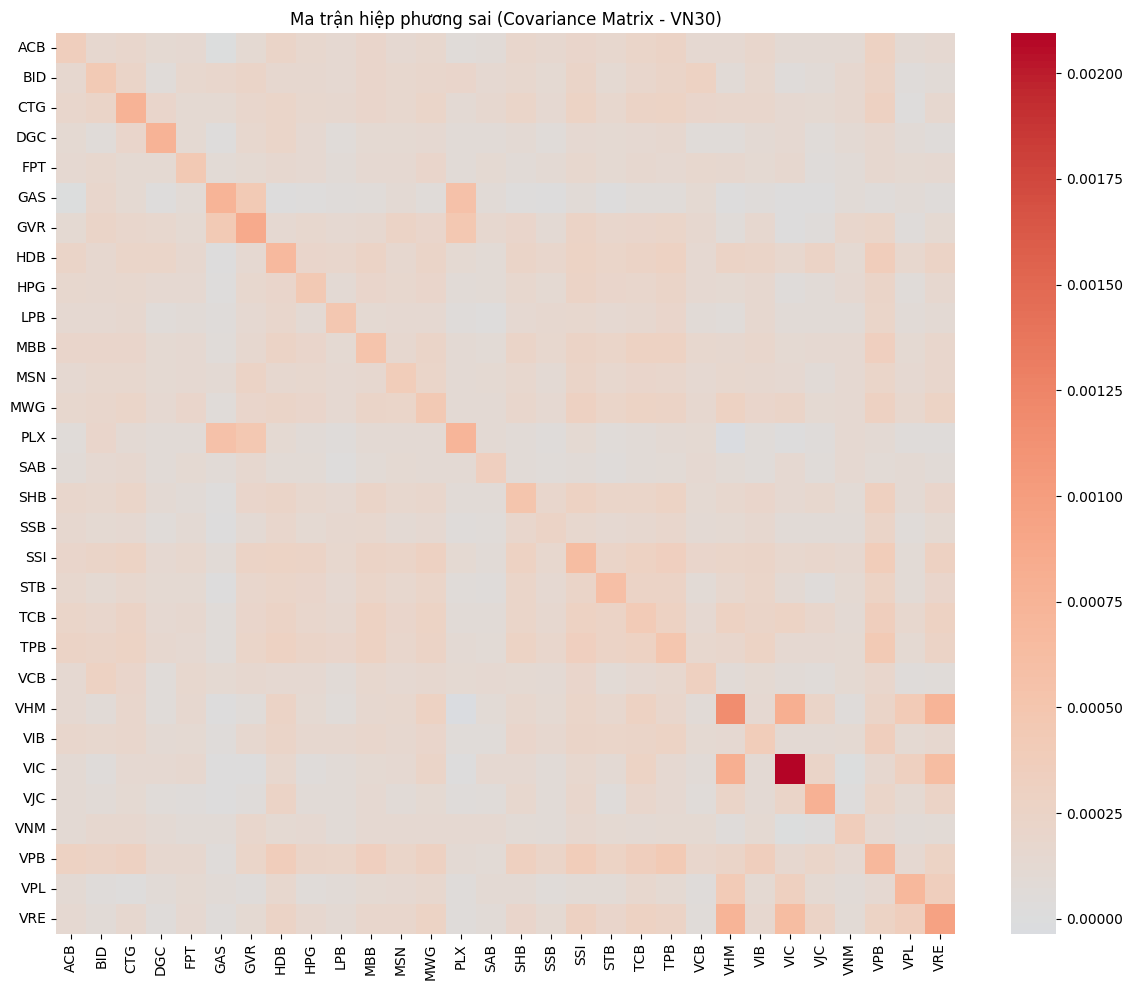

In [80]:
# 2.2 MA TRẬN HIỆP PHƯƠNG SAI

# Tính ma trận hiệp phương sai từ dữ liệu return đã center
cov_matrix = np.cov(X_centered.values, rowvar=False)

print("Kích thước ma trận hiệp phương sai:", cov_matrix.shape)

# Đưa về DataFrame để gắn nhãn ticker cho hàng/cột
cov_df = pd.DataFrame(cov_matrix, index=X.columns, columns=X.columns)

# Tạo khung hình
plt.figure(figsize=(12, 10))

# Vẽ heatmap với nhãn là mã cổ phiếu
sns.heatmap(
    cov_df,            # ma trận hiệp phương sai có nhãn ticker
    cmap="coolwarm",   # bảng màu: đỏ (dương), xanh (âm)
    center=0,          # lấy 0 làm điểm trung tâm
    xticklabels=True,  # hiện mã cổ phiếu trục X
    yticklabels=True   # hiện mã cổ phiếu trục Y
)

# Đặt tiêu đề và chỉnh góc chữ
plt.title("Ma trận hiệp phương sai (Covariance Matrix - VN30)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

## **Nhận xét ma trận hiệp phương sai**

Ma trận hiệp phương sai có kích thước `(30, 30)`, tương ứng với 30 cổ phiếu trong rổ VN30.  
Các phần tử trên đường chéo phản ánh phương sai riêng của từng mã; nhìn chung nổi bật hơn phần lớn phần tử ngoài đường chéo, cho thấy biến động riêng từng cổ phiếu vẫn là thành phần quan trọng trong cấu trúc rủi ro.

Ở phần ngoài đường chéo, đa số ô có cường độ màu nhạt đến trung bình, hàm ý mức đồng biến giữa nhiều cặp cổ phiếu không quá cực đoan. Tuy vậy, vẫn xuất hiện một số vùng đậm hơn quanh các mã trụ, cho thấy có những nhóm cổ phiếu liên kết biến động chặt hơn mặt bằng chung.

Như vậy, rổ VN30 vừa có yếu tố biến động riêng theo từng mã, vừa có yếu tố đồng biến theo nhóm. Việc quản trị danh mục vì thế cần theo dõi đồng thời cả rủi ro đơn lẻ và mức liên kết giữa các cổ phiếu.

In [81]:
# 2.3 PHÂN RÃ TRỊ RIÊNG - VECTOR RIÊNG
eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)

print("Số lượng trị riêng:", len(eig_vals))
print("Kích thước ma trận vector riêng:", eig_vecs.shape)

Số lượng trị riêng: 30
Kích thước ma trận vector riêng: (30, 30)


- `Số lượng trị riêng: 30` nghĩa là PCA tách được **30 thành phần chính** (bằng đúng số biến đầu vào).
- `Kích thước ma trận vector riêng: (30, 30)` nghĩa là có **30 vector riêng**, mỗi vector dài 30 phần tử.
- Mỗi vector riêng tương ứng một trục thành phần chính (PC), dùng để chiếu dữ liệu sang không gian PCA.

In [82]:
# 2.4 SẮP XẾP GIẢM DẦN THEO TRỊ RIÊNG

idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[idx]
eig_vecs = eig_vecs[:, idx]

print("Top 5 trị riêng:", eig_vals[:5])

Top 5 trị riêng: [0.00563241 0.00260267 0.00156314 0.00098595 0.0007626 ]


### Nhân tố biến động chính
Trị riêng lớn nhất: λ₁ = 0.00563
Lớn hơn rõ rệt so với các trị riêng còn lại
Điều này cho thấy: Biến động của VN30 bị chi phối mạnh bởi một nhân tố chính duy nhất, thường được hiểu là yếu tố thị trường chung.

### Mức độ suy giảm trị riêng
Từ λ₁ sang λ₂ giảm mạnh (hơn 50%)
Các trị riêng tiếp theo giảm dần

Ý nghĩa: Sau yếu tố thị trường chung, các yếu tố ngành và đặc thù từng cổ phiếu có mức ảnh hưởng nhỏ hơn đáng kể.

### Ý nghĩa trong PCA
Một vài trị riêng đầu tiên chiếm phần lớn tổng phương sai

Dữ liệu có thể được giảm chiều hiệu quả

Kết luận: Khoảng 3–5 thành phần chính đã đủ để giải thích phần lớn biến động của 30 cổ phiếu VN30.

### Liên hệ tài chính

Sự tồn tại của một trị riêng vượt trội cho thấy thị trường có mức độ đồng biến cao, nghĩa là các cổ phiếu thường chịu tác động cùng một xu hướng chung.

### Kết luận

PCA cho thấy VN30 có cấu trúc biến động tập trung, trong đó nhân tố đầu tiên đóng vai trò đại diện cho xu hướng chung của toàn thị trường.

In [83]:
# 2.5 TỶ LỆ PHƯƠNG SAI GIẢI THÍCH

explained_var_ratio = eig_vals / eig_vals.sum()
cum_explained_var = np.cumsum(explained_var_ratio)

print("Tỷ lệ phương sai giải thích PC1-PC5:", explained_var_ratio[:5])
print("Tỷ lệ tích lũy PC1-PC5:", cum_explained_var[:5])

Tỷ lệ phương sai giải thích PC1-PC5: [0.29844576 0.13790832 0.08282638 0.05224298 0.04040808]
Tỷ lệ tích lũy PC1-PC5: [0.29844576 0.43635407 0.51918045 0.57142343 0.61183151]


- **Tỷ lệ phương sai giải thích PC1-PC5** cho biết mức đóng góp riêng của từng thành phần:
  - PC1: ~29.84%
  - PC2: ~13.79%
  - PC3: ~8.28%
  - PC4: ~5.22%
  - PC5: ~4.04%

- **Tỷ lệ tích lũy PC1-PC5** cho biết tổng mức giải thích khi cộng dần các thành phần:
  - PC1: ~29.84%
  - PC1+PC2: ~43.64%
  - PC1+PC2+PC3: ~51.92%
  - PC1..PC4: ~57.14%
  - PC1..PC5: ~61.18%

- Kết luận:
  - PC1 là nhân tố quan trọng nhất.
  - 5 thành phần đầu đã giữ lại khoảng **61%** thông tin biến động của toàn bộ rổ VN30.

Điều này cho thấy:
- Một phần lớn biến động thị trường có thể được mô tả bằng một số ít thành phần chính.
- Không có một thành phần đơn lẻ nào giải thích toàn bộ biến động.
- Cần kết hợp nhiều thành phần để phản ánh đầy đủ cấu trúc dữ liệu.

In [84]:
# 2.6 CHIẾU DỮ LIỆU LÊN PC1, PC2

X_pca = X_centered.values @ eig_vecs[:, :2]

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=X.index
)

display(pca_df.head())

,PC1,PC2
Date,,
2025-05-14,-0.055481,-0.032538
2025-05-15,-0.018735,-0.032978
2025-05-16,0.059579,0.037194
2025-05-19,0.034031,0.077476
2025-05-20,-0.080412,0.070490


- Bảng này là điểm số PCA theo ngày sau khi chiếu dữ liệu lên 2 thành phần đầu: `PC1` và `PC2`.
- Mỗi dòng là một phiên giao dịch; mỗi giá trị cho biết mức độ “tham gia” của nhân tố đó trong ngày.

- Cách đọc nhanh:
  - Giá trị dương: cùng chiều với nhân tố.
  - Giá trị âm: ngược chiều với nhân tố.
  - Độ lớn tuyệt đối càng cao: tác động của nhân tố trong ngày đó càng mạnh.

- Ví dụ:
  - `2025-05-16`: `PC1 = 0.059579`, `PC2 = 0.037194` → cả hai nhân tố cùng nghiêng theo chiều dương.
  - `2025-05-20`: `PC1 = -0.080412`, `PC2 = 0.070490` → nhân tố chung (PC1) nghiêng âm, nhưng nhân tố phụ (PC2) nghiêng dương.

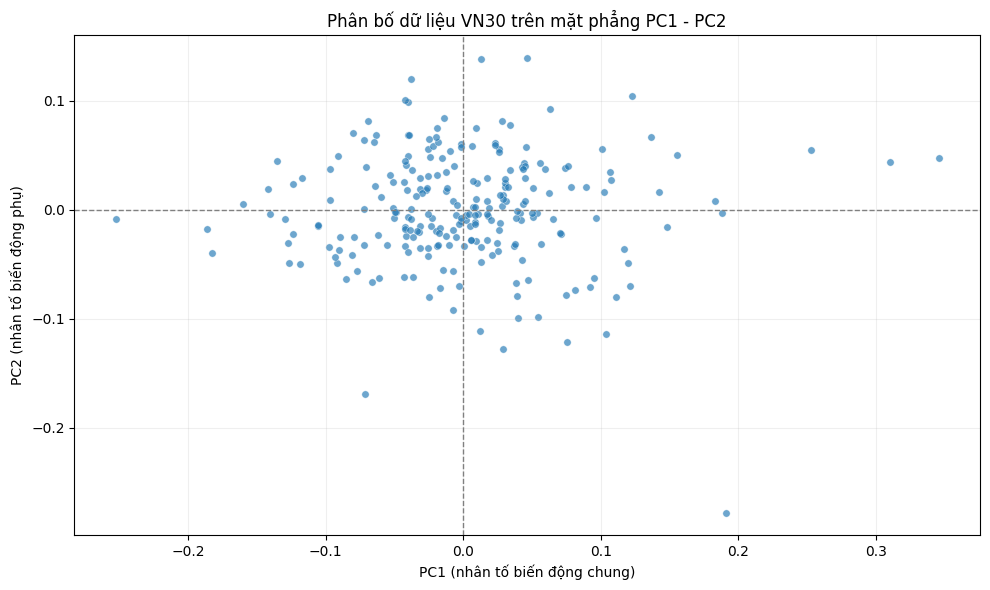

In [85]:
# 2.7 VẼ SCATTER PC1 - PC2

plt.figure(figsize=(10, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.65,
    s=28,
    edgecolors="white",
    linewidths=0.4
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)

plt.title("Phân bố dữ liệu VN30 trên mặt phẳng PC1 - PC2")
plt.xlabel("PC1 (nhân tố biến động chung)")
plt.ylabel("PC2 (nhân tố biến động phụ)")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### **Mục đích biểu đồ PC1–PC2**
Biểu đồ scatter PC1–PC2 dùng để trực quan hóa dữ liệu sau PCA:

- Mỗi điểm đại diện cho một ngày giao dịch.
- Trục PC1 phản ánh nhân tố biến động chung của thị trường.
- Trục PC2 phản ánh phần biến động phụ giữa các cổ phiếu.

Mục tiêu là quan sát mức độ phân tán, khả năng phân cụm và các điểm bất thường.

### **Nhận xét biểu đồ**

- **Điểm dữ liệu tập trung quanh gốc (0,0):**  
  Phần lớn phiên giao dịch có mức biến động vừa phải, không lệch mạnh theo một hướng cố định.

- **Phân bố tương đối cân bằng quanh hai trục:**  
  Thị trường có cả phiên tăng và giảm; không thấy thiên lệch dài hạn rõ rệt chỉ từ mặt phẳng PC1–PC2.

- **Độ phân tán theo PC1 lớn hơn PC2:**  
  Biến động theo nhân tố chung nổi bật hơn nhân tố phụ, phù hợp với kết quả phương sai giải thích (PC1 lớn nhất).

- **Có một số điểm xa cụm chính (outliers):**  
  Đây là các phiên có biến động mạnh bất thường, có thể liên quan đến thông tin/sự kiện thị trường.

- **Không xuất hiện cụm tách biệt rõ ràng:**  
  Dữ liệu có xu hướng biến động liên tục theo thời gian hơn là chia thành các “nhóm trạng thái” riêng biệt.

### **Kết luận**
Biểu đồ PC1–PC2 cho thấy PCA đã biểu diễn được cấu trúc chính của dữ liệu VN30 trên không gian 2 chiều: nhân tố chung (PC1) là trục chi phối chính, trong khi PC2 phản ánh phần khác biệt bổ sung giữa các cổ phiếu.


### **3. Phân tích và trực quan hóa thành phần chính đầu tiên (PC1)**

In [86]:
# DỰNG PC1_index TỪ KẾT QUẢ PCA ĐÃ CÓ

# Lấy vector riêng của PC1
pc1_vector = eig_vecs[:, 0]

# Tạo chuỗi thời gian PC1_index = X_centered @ pc1_vector
PC1_index = pd.Series(
    X_centered.values @ pc1_vector,
    index=X_centered.index,
    name="PC1_index"
)

print("Kích thước PC1_index:", PC1_index.shape)
display(PC1_index.head())

Kích thước PC1_index: (241,)


,PC1_index
Date,
2025-05-14,-0.055481
2025-05-15,-0.018735
2025-05-16,0.059579
2025-05-19,0.034031
2025-05-20,-0.080412


Kết quả cho thấy chuỗi `PC1_index` đã được tạo đúng dạng chuỗi thời gian với `241` quan sát, tương ứng đầy đủ số phiên giao dịch trong dữ liệu return.

Năm giá trị đầu tiên của `PC1_index` có cả dấu âm và dương, cho thấy thành phần chính thứ nhất biến động hai chiều theo từng ngày giao dịch, không cố định một hướng.  
Điều này phù hợp với bản chất của PC1: phản ánh cường độ và hướng dịch chuyển của nhân tố biến động chung tại mỗi thời điểm.

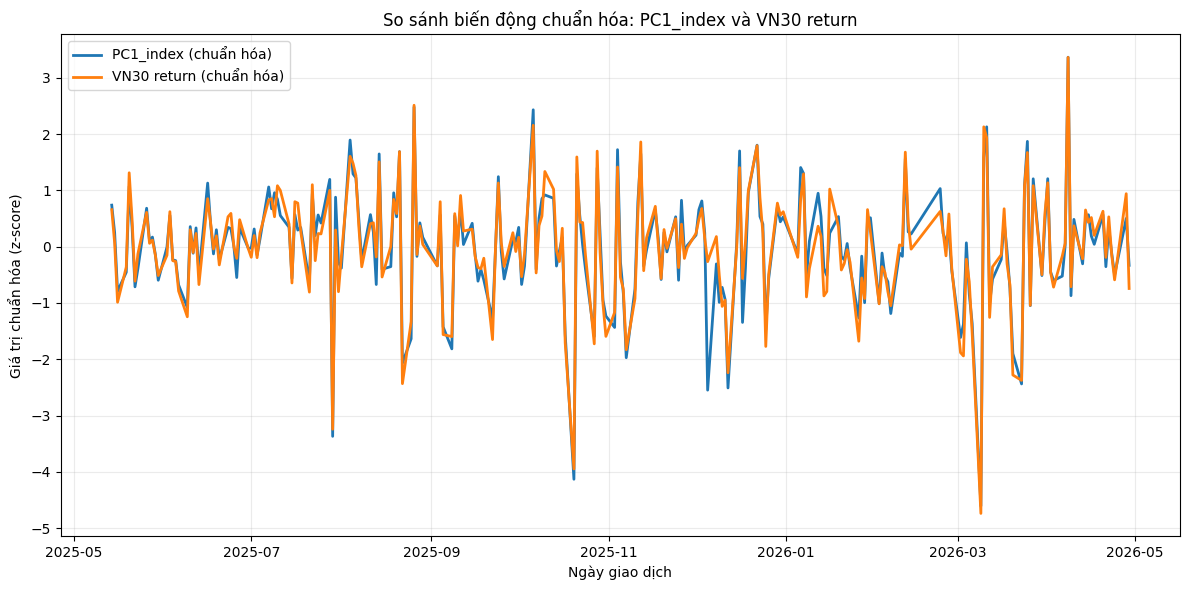

In [89]:
# Ghép theo cùng ngày giao dịch
tmp = pd.concat([PC1_index, vn30_return], axis=1, join="inner").dropna()
tmp.columns = ["PC1_index", "VN30_return"]

# Nếu PC1 ngược chiều VN30 thì đảo dấu để nhìn trực quan cùng chiều
if tmp["PC1_index"].corr(tmp["VN30_return"]) < 0:
    tmp["PC1_used"] = -tmp["PC1_index"]
else:
    tmp["PC1_used"] = tmp["PC1_index"]

# Chuẩn hóa z-score từng chuỗi để so sánh cùng thang đo (không dùng cumulative giả lập)
tmp["PC1_std"] = (tmp["PC1_used"] - tmp["PC1_used"].mean()) / tmp["PC1_used"].std(ddof=1)
tmp["VN30_std"] = (tmp["VN30_return"] - tmp["VN30_return"].mean()) / tmp["VN30_return"].std(ddof=1)

# Vẽ biểu đồ so sánh biến động chuẩn hóa
plt.figure(figsize=(12, 6))
plt.plot(tmp.index, tmp["PC1_std"], label="PC1_index (chuẩn hóa)", linewidth=2)
plt.plot(tmp.index, tmp["VN30_std"], label="VN30 return (chuẩn hóa)", linewidth=2)

plt.title("So sánh biến động chuẩn hóa: PC1_index và VN30 return")
plt.xlabel("Ngày giao dịch")
plt.ylabel("Giá trị chuẩn hóa (z-score)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Biểu đồ biến động chuẩn hóa cho thấy `PC1_index` và `VN30_return` có nhiều đoạn đi cùng nhịp theo thời gian: các nhịp tăng/giảm mạnh thường xuất hiện gần nhau ở cả hai chuỗi. Điều này cho thấy thành phần chính thứ nhất đã bắt được phần quan trọng của biến động thị trường.

Bên cạnh đó, vẫn có một số thời điểm hai đường lệch biên độ hoặc lệch nhịp cục bộ, phản ánh việc PC1 chưa thể bao quát toàn bộ chuyển động của chỉ số trong mọi phiên. Nói cách khác, ngoài PC1 vẫn còn phần thông tin nằm ở các thành phần chính tiếp theo.

In [92]:
# Hệ số tương quan giữa PC1_used và VN30_return

corr_df = pd.concat([tmp["PC1_used"], tmp["VN30_return"]], axis=1).dropna()
corr_df.columns = ["PC1_used", "VN30_return"]

corr_value = corr_df["PC1_used"].corr(corr_df["VN30_return"])
print("Hệ số tương quan:", round(corr_value, 4))

Hệ số tương quan: 0.9606


In [91]:
# LOADINGS CỦA PC1

loadings_df = pd.DataFrame({
    "Ticker": X.columns,
    "PC1_loading": eig_vecs[:, 0]
}).sort_values("PC1_loading", key=np.abs, ascending=False)

print("Top 10 cổ phiếu có |loading| lớn nhất trên PC1:")
display(loadings_df.head(10))

Top 10 cổ phiếu có |loading| lớn nhất trên PC1:


,Ticker,PC1_loading
24,VIC,-0.274320
27,VPB,-0.263689
22,VHM,-0.263135
29,VRE,-0.257298
17,SSI,-0.236003
20,TPB,-0.224650
7,HDB,-0.219781
19,TCB,-0.219571
12,MWG,-0.210570
2,CTG,-0.199590


Hệ số tương quan giữa `PC1_used` và `VN30_return` đạt `0.9606`, cho thấy mức đồng biến rất mạnh giữa nhịp PC1 và biến động ngày của chỉ số VN30 trong mẫu nghiên cứu. Kết quả này củng cố vai trò của PC1 như một thành phần đại diện cho yếu tố biến động chung của rổ VN30.

Kết hợp với bảng loadings, các mã có `|loading|` lớn tập trung nhiều ở nhóm tài chính (như `VPB`, `TCB`, `TPB`, `HDB`, `CTG`, `SSI`) và nhóm bất động sản vốn hóa lớn (`VIC`, `VHM`, `VRE`), cùng một số mã tiêu dùng lớn (`MWG`). Điều này hàm ý chuyển động của PC1 chịu ảnh hưởng mạnh từ nhóm cổ phiếu dẫn dắt trong VN30.

Về ý nghĩa tài chính, PC1 có thể được diễn giải là nhân tố chu kỳ của nhóm bluechip dẫn dắt VN30 trong giai đoạn phân tích. Nói cách khác, khi các nhóm cổ phiếu này đồng thuận biến động, giá trị PC1 thay đổi rõ và bám sát nhịp của chỉ số.